# BERTopic-Based Song Recommendation System

This notebook implements a comprehensive BERTopic-based music recommendation system as outlined in the research plan. It includes:

1. **Data preprocessing** (adapted from LDA pipeline)
2. **BERTopic model training** with transformer embeddings
3. **LLM-assisted topic labeling** using GPT for interpretable topic names
4. **Song/Artist similarity calculation** using cosine similarity on topic distributions
5. **Diversity-aware recommendations** using Maximal Marginal Relevance (MMR)
6. **Comprehensive evaluation** and visualization tools

## 🎯 Key Features:
- **Transformer-based embeddings** for better semantic understanding
- **Automatic topic discovery** with HDBSCAN clustering
- **Human-readable topic labels** generated via LLM prompts
- **Artist-level aggregation** of topic distributions
- **Diversity re-ranking** to avoid echo chambers
- **Interactive visualizations** and analysis tools

In [53]:
# Core imports for BERTopic and preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import pickle
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# BERTopic and related libraries
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# For preprocessing (adapted from LDA notebook)
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer
import re

# For similarity and recommendations
from scipy.spatial.distance import cosine
from difflib import SequenceMatcher

# For LLM topic labeling with LangChain and OpenAI
from langchain_openai import ChatOpenAI
from langchain.schema import HumanMessage, SystemMessage
from langchain.prompts import PromptTemplate
import openai
from dotenv import load_dotenv

# Download necessary NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
tokenizer = RegexpTokenizer(r"[A-Za-z]+(?:'[A-Za-z]*)?")

print("📦 All libraries imported successfully!")
print("🚀 Ready to build BERTopic-based song recommendation system!")
print("🤖 LangChain + OpenAI integration ready for topic labeling!")

# Note: Make sure to set your OpenAI API key
load_dotenv(override=True)  # Load environment variables from .env file
openai_api_key = os.getenv("OPENAI_API_KEY")

📦 All libraries imported successfully!
🚀 Ready to build BERTopic-based song recommendation system!
🤖 LangChain + OpenAI integration ready for topic labeling!


In [54]:
# ===== GPU SETUP AND DETECTION =====

import torch


def setup_gpu_environment():
    """Setup GPU environment with proper memory management"""
    # Check CUDA availability

    cuda_available = torch.cuda.is_available()
    device_count = torch.cuda.device_count()
    print("🖥️  GPU Environment Setup:")
    print(f"   CUDA Available: {cuda_available}")

    if cuda_available:
        print(f"   GPU Device Count: {device_count}")
        for i in range(device_count):
            gpu_name = torch.cuda.get_device_name(i)
            gpu_memory = torch.cuda.get_device_properties(
                i).total_memory / 1024**3
            print(f"   GPU {i}: {gpu_name} ({gpu_memory:.1f} GB)")

        # Set memory management

        torch.cuda.empty_cache()

        # Set memory fraction to avoid OOM

        torch.cuda.set_per_process_memory_fraction(0.8)
        device = torch.device("cuda")
        print(f"   ✅ Using GPU: {torch.cuda.get_device_name(0)}")

    else:
        device = torch.device("cpu")
        print("   ⚠️  CUDA not available. Using CPU.")
        print(
            "   💡 To enable GPU: pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118"
        )

    # Set environment variables for optimal performance
    os.environ["TOKENIZERS_PARALLELISM"] = "false"  # Avoid warnings
    return device, cuda_available


def clear_gpu_memory():
    """Clear GPU memory cache"""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()
        print("🧹 GPU memory cleared")


def get_gpu_memory_usage():
    """Get current GPU memory usage"""
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        cached = torch.cuda.memory_reserved() / 1024**3
        return f"GPU Memory - Allocated: {allocated:.2f} GB, Cached: {cached:.2f} GB"
    return "GPU not available"


# Initialize GPU environment
device, cuda_available = setup_gpu_environment()
print(f"\n🎯 Device selected: {device}")

🖥️  GPU Environment Setup:
   CUDA Available: True
   GPU Device Count: 1
   GPU 0: NVIDIA GeForce RTX 3050 Laptop GPU (4.0 GB)
   ✅ Using GPU: NVIDIA GeForce RTX 3050 Laptop GPU

🎯 Device selected: cuda


In [55]:
# Load and inspect the data
import pandas as pd
df = pd.read_csv('../Lyrics_extraction/scraped_lyrics_no_metadata_combined.csv', encoding='utf-8')

print(f"📊 Dataset Overview:")
print(f"   Songs: {len(df):,}")
print(f"   Artists: {df['artist'].nunique():,}")
print(f"   Columns: {list(df.columns)}")

# Display sample data
print(f"\n🎵 Sample songs:")
sample_df = df.head(3)[['artist', 'song_title']].reset_index(drop=True)
for i, row in sample_df.iterrows():
    print(f"   {i+1}. {row['artist']} - {row['song_title']}")

# Check for missing values
print(f"\n🔍 Data quality check:")
print(f"   Missing lyrics: {df['lyrics'].isna().sum()}")


print(f"\n📝 Average lyrics length: {df['lyrics'].str.len().mean():.0f} characters")
df.head()

📊 Dataset Overview:
   Songs: 5,949
   Artists: 600
   Columns: ['artist', 'song_title', 'lyrics']

🎵 Sample songs:
   1. 21 Savage - Bank Account
   2. 21 Savage - Ghostface Killers
   3. 21 Savage - Glock in My Lap

🔍 Data quality check:
   Missing lyrics: 0

📝 Average lyrics length: 1800 characters


,artist,song_title,lyrics
0,21 Savage,Bank Account,"[Intro]\nOoh, ooh, oh, oh, oh, ow, ow\nWow, wo..."
1,21 Savage,Ghostface Killers,[Intro: Young Thug & Offset]\nMetro Boomin wan...
2,21 Savage,Glock in My Lap,"[Intro]\nY'all niggas stop playin', nigga\nY'a..."
3,21 Savage,No Heart,"[Intro]\nSouthside, Southside on the, Southsid..."
4,21 Savage,Red Opps,"[Intro]\nYeah, yeah, yeah\nI pull up roll the ..."


In [56]:
# ===== PREPROCESSING FUNCTIONS (Adapted from LDA notebook) =====



def clean_lyrics_metadata(lyrics_text):
    """
    Clean lyrics by finding the first structural marker [Something] or "Read More" and keeping everything from there.

    Args:
        lyrics_text (str): Raw lyrics text with metadata

    Returns:
        str: Cleaned lyrics starting from first structural marker or after "Read More"
    """
    if pd.isna(lyrics_text) or not lyrics_text:
        return ""

    text = str(lyrics_text)

    # Pattern 1: Find "Read More" and take everything after it
    read_more_pattern = r"read more\s*"
    read_more_match = re.search(read_more_pattern, text, re.IGNORECASE)

    # Pattern 2: Find structural markers [Something]
    structural_pattern = r"\[(Intro|Chorus|Verse|Pre-Chorus|Bridge|.*).*?\]"
    structural_match = re.search(structural_pattern, text)

    # Pattern 3: Find "Lyrics" followed by any alphabetic character
    lyrics_pattern = r"Lyrics(?=[\S])"
    lyrics_match = re.search(lyrics_pattern, text)

    read_more_pos = read_more_match.start() if read_more_match else None
    structural_pos = structural_match.start() if structural_match else None
    lyrics_pos = lyrics_match.start() if lyrics_match else None

    if read_more_pos:
        # If "Read More" appears => just take everything after it
        start_index = read_more_match.end()
        cleaned_text = text[start_index:].strip()
        return cleaned_text
    elif structural_match:
        # Structural marker appears first - take everything from it
        start_index = structural_match.start()
        cleaned_text = text[start_index:].strip()
        return cleaned_text
    elif lyrics_pos:
        # "Lyrics" appears first - take everything from it
        start_index = lyrics_match.end()
        cleaned_text = text[start_index:].strip()
        return cleaned_text
    else:
        # Neither pattern found, return original text
        return text.strip()

def clean_lyrics_for_bertopic(text):
    """
    Clean lyrics specifically for BERTopic processing
    BERTopic works better with sentences/phrases rather than individual tokens
    """
    if pd.isna(text) or not text:
        return ""
    
    text = str(text)
    
    # Remove structural markers like [Chorus], [Verse], etc.
    text = re.sub(r'\[.*?\]', '', text)
    
    # Clean up whitespace and newlines
    text = re.sub(r'\n+', ' ', text)  # Replace newlines with spaces
    text = re.sub(r'\s+', ' ', text)  # Normalize whitespace    
    
    return text.strip()

def process_new_document(text):
    text = clean_lyrics_metadata(text)
    text = clean_lyrics_for_bertopic(text)
    return text.strip()

def preprocess_for_bertopic(texts, min_length=0, verbose=True):
    """
    Preprocess lyrics corpus for BERTopic
    """
    if verbose:
        print("🔄 Preprocessing lyrics for BERTopic...")
    
    processed_docs = []
    skipped_count = 0
    
    for i, text in enumerate(texts):
        cleaned_text = clean_lyrics_for_bertopic(text)
        
        processed_docs.append(cleaned_text)
     
        if verbose and (i + 1) % 500 == 0:
            print(f"   Processed {i + 1}/{len(texts)} documents")
    
    if verbose:
        valid_docs = len([doc for doc in processed_docs if doc])
        print(f"✅ Preprocessing complete:")
        print(f"   Valid documents: {valid_docs:,}")
        print(f"   Skipped (too short): {skipped_count:,}")
        print(f"   Success rate: {valid_docs/len(texts)*100:.1f}%")
    
    return processed_docs

# Apply preprocessing
print("🧹 Cleaning lyrics for BERTopic analysis...")
df['lyrics_cleaned'] = preprocess_for_bertopic(df['lyrics'])

# Filter out empty documents
initial_count = len(df)
df = df[df['lyrics_cleaned'].str.len() > 0].reset_index(drop=True)
print(f"📊 Filtered dataset: {len(df):,} songs (removed {initial_count - len(df)} invalid entries)")

# Show sample cleaned lyrics
print(f"\n📝 Sample cleaned lyrics:")
sample_text = df['lyrics_cleaned'].iloc[0][:300]
print(f"   {sample_text}...")

🧹 Cleaning lyrics for BERTopic analysis...
🔄 Preprocessing lyrics for BERTopic...
   Processed 500/5949 documents
   Processed 1000/5949 documents
   Processed 1500/5949 documents
   Processed 2000/5949 documents
   Processed 2500/5949 documents
   Processed 3000/5949 documents
   Processed 3500/5949 documents
   Processed 4000/5949 documents
   Processed 4500/5949 documents
   Processed 5000/5949 documents
   Processed 5500/5949 documents
✅ Preprocessing complete:
   Valid documents: 5,946
   Skipped (too short): 0
   Success rate: 99.9%
📊 Filtered dataset: 5,946 songs (removed 3 invalid entries)

📝 Sample cleaned lyrics:
   Ooh, ooh, oh, oh, oh, ow, ow Wow, wow, wow, ah, ow, ow, ow I buy a new car for the bitch (For real) I tear down the mall with the bitch (For real) You can't even talk to the bitch (No) She fucking with bosses and shit (On God) I pull up in 'Raris and shit (Skrrt) With choppers and Harleys and shit (...


In [57]:
# ===== TOPIC MODELING CONFIGURATION =====
import bertopic
from sklearn.cluster import KMeans
from torch import mul
from bertopic.representation import OpenAI
print("🤖 Configuring BERTopic components...")

# 1. Sentence Transformer for embeddings
print("   Loading sentence transformer model...")
docs = df['lyrics_cleaned'].tolist()
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedding_model.encode(docs, show_progress_bar=True)
print(f"   ✅ Loaded: {embedding_model.get_sentence_embedding_dimension()}D embeddings")

# 2. UMAP for dimensionality reduction
print("   Configuring UMAP for dimensionality reduction...")
umap_model = UMAP(n_neighbors=15, n_components=5,
                  min_dist=0.0, metric='cosine', random_state=42)
print("   ✅ UMAP configured")

# 3. HDBSCAN for clustering
print("   Configuring HDBSCAN(KMeans) for clustering...")
hdbscan_model = HDBSCAN(min_cluster_size=5, metric='euclidean',
                        cluster_selection_method='leaf', prediction_data=True)

print("   ✅ HDBSCAN configured")

# 4. Vectorizer for topic representation (simplified to avoid parameter conflicts)
print("   Configuring CountVectorizer...")
vectorizer_model = CountVectorizer(
    stop_words="english", min_df=2, ngram_range=(1, 1))
print("   ✅ CountVectorizer configured")
# 5. Create BERTopic instance
print("   Creating BERTopic model...")

prompt = """
I have a topic that contains the following documents:
[DOCUMENTS]
The topic is described by the following keywords: [KEYWORDS]
Note that, all of these topics are related to musical themes.
Based on the information above, extract a short but highly descriptive topic label of at most 5 words. Make sure it is in the following format:
topic: <topic label>
"""


client = openai.OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
openai_model = OpenAI(client, model="gpt-4o",
                      exponential_backoff=True, chat=True, prompt=prompt,
            temperature=0.0,  # Set to 0 for consistent outputs
            max_tokens=80,    # Reduced for more concise labels
            api_key=os.getenv("OPENAI_API_KEY"),
            seed=42,          # For reproducible outputs
            top_p=1.0,  )

# All representation models
representation_model = {
    "OpenAI": openai_model,  # Uncomment if you will use OpenAI
}

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    representation_model = representation_model,  # Use OpenAI for topic representation
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True,
    language="english", #will be ignored if embedding_model is provided
    embedding_model=embedding_model, 
    nr_topics=11,
    # Smaller topics allowed       # Let BERTopic determine optimal number
    top_n_words=20,  # Number of words per topic
)

print("   ✅ BERTopic model ready for training!")

print(f"\n📋 Model Configuration Summary:")
print(f"   Embedding: {embedding_model.get_sentence_embedding_dimension()}D sentence-transformers")
print(f"   UMAP: {umap_model.n_components}D reduction")
print(f"   Clustering: HDBSCAN")
print(f"   Vectorizer: {vectorizer_model.ngram_range} n-grams, max_features={vectorizer_model.max_features}")
print(f"   Vocabulary filtering: default settings (no min_df/max_df constraints)")

🤖 Configuring BERTopic components...
   Loading sentence transformer model...


Batches:   0%|          | 0/186 [00:00<?, ?it/s]

   ✅ Loaded: 384D embeddings
   Configuring UMAP for dimensionality reduction...
   ✅ UMAP configured
   Configuring HDBSCAN(KMeans) for clustering...
   ✅ HDBSCAN configured
   Configuring CountVectorizer...
   ✅ CountVectorizer configured
   Creating BERTopic model...
   ✅ BERTopic model ready for training!

📋 Model Configuration Summary:
   Embedding: 384D sentence-transformers
   UMAP: 5D reduction
   Clustering: HDBSCAN
   Vectorizer: (1, 1) n-grams, max_features=None
   Vocabulary filtering: default settings (no min_df/max_df constraints)


In [58]:
# ===== TRAIN BERTOPIC MODEL =====

print(f"🚀 Training BERTopic model on song lyrics...")
print(f"📊 Training on {len(df)} songs")

# Prepare documents
documents = df['lyrics_cleaned'].tolist()

print(f"\n⏳ This may take several minutes for large datasets...")
print("🔄 Training in progress...")

# Train BERTopic model
topics, probabilities = topic_model.fit_transform(documents)
# topic_model.reduce_outliers(documents=documents, topics= topics,probabilities= probabilities, strategy="c-tf-idf")
print(f"\n✅ BERTopic training completed!")
print(f"📊 Results:")
print(f"   Total topics discovered: {len(set(topics))}")
print(f"   Documents assigned to topics: {len([t for t in topics if t != -1])}")
print(f"   Outlier documents (topic -1): {len([t for t in topics if t == -1])}")

# Get topic info
topic_info = topic_model.get_topic_info()
print(f"\n🏷️ Topic size distribution:")
for i, row in topic_info.head(10).iterrows():
    if row['Topic'] != -1:
        topic_words = [word.split('_')[0] for word in row['Representation']]
        print(f"   Topic {row['Topic']:2d}: {row['Count']:4d} songs - {', '.join(topic_words)}")

# Store results in dataframe
df['topic'] = topics
df['topic_probability'] = probabilities.max(axis=1) if probabilities is not None else [0.0] * len(topics)

print(f"\n📈 Assignment statistics:")
print(f"   Average topic confidence: {df['topic_probability'].mean():.3f}")
print(f"   Songs with high confidence (>0.5): {(df['topic_probability'] > 0.5).sum()}")

print(f"\n🎉 BERTopic training complete!")

2025-07-20 23:43:37,321 - BERTopic - Embedding - Transforming documents to embeddings.


🚀 Training BERTopic model on song lyrics...
📊 Training on 5946 songs

⏳ This may take several minutes for large datasets...
🔄 Training in progress...


Batches:   0%|          | 0/186 [00:00<?, ?it/s]

2025-07-20 23:43:57,432 - BERTopic - Embedding - Completed ✓
2025-07-20 23:43:57,433 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-07-20 23:44:09,880 - BERTopic - Dimensionality - Completed ✓
2025-07-20 23:44:09,884 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-07-20 23:44:26,698 - BERTopic - Cluster - Completed ✓
2025-07-20 23:44:26,700 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-07-20 23:44:29,074 - BERTopic - Representation - Completed ✓
2025-07-20 23:44:29,077 - BERTopic - Topic reduction - Reducing number of topics
2025-07-20 23:44:29,115 - BERTopic - Representation - Fine-tuning topics using representation models.
100%|██████████| 11/11 [00:10<00:00,  1.05it/s]
2025-07-20 23:44:42,544 - BERTopic - Representation - Completed ✓
2025-07-20 23:44:42,550 - BERTopic - Topic reduction - Reduced number of topics from 171 to 11



✅ BERTopic training completed!
📊 Results:
   Total topics discovered: 11
   Documents assigned to topics: 1945
   Outlier documents (topic -1): 4001

🏷️ Topic size distribution:
   Topic  0: 1526 songs - oh, love, know, yeah, don, just, like, ooh, baby, ll, la, let, got, ve, time, make, want, way, girl, wanna
   Topic  1:  142 songs - nigga, bitch, yeah, fuck, like, got, ain, niggas, dick, don, know, shit, bubble, cause, just, man, ma, money, ass, new
   Topic  2:   93 songs - que, el, te, la, che, tu, se, en, si, yo, non, mi, il, lo, una, di, tú, por, es, amor
   Topic  3:   60 songs - jesus, lord, holy, praise, god, hallelujah, amazing, yes, forever, oh, king, worship, glory, sing, yeah, trust, faithful, ho, let, lifted
   Topic  4:   50 songs - oh, yeah, na, 너무, peek, du, gee, 다시, 내가, eh, ooh, 거야, ah, 너의, 너를, 없는, run, 나를, 말해봐, 없어
   Topic  5:   33 songs - whoop, revolution, war, world, ya, liar, america, didn, don, start, bullet, anarchy, got, saints, run, hey, law, hands, burns, h

In [79]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,OpenAI,Representative_Docs
0,-1,4001,-1_oh_don_yeah_love,"[oh, don, yeah, love, like, know, just, got, l...",[Romantic and Passionate Encounters],[You were workin' as a waitress in a cocktail ...
1,0,1526,0_oh_love_know_yeah,"[oh, love, know, yeah, don, just, like, ooh, b...","[Love, Emotion, and Reflection]","[Now you want my love, well, that's alright We..."
2,1,142,1_nigga_bitch_yeah_fuck,"[nigga, bitch, yeah, fuck, like, got, ain, nig...",[Hip-Hop and Rap Culture],"[Ugh, AK on my nightstand, right next to that ..."
3,2,93,2_que_el_te_la,"[que, el, te, la, che, tu, se, en, si, yo, non...",[Themes in Latin Music Lyrics],"[¡Prrrra! Gang, damn, esskeetit, ¡wuh-uh! (¡Pr..."
4,3,60,3_jesus_lord_holy_praise,"[jesus, lord, holy, praise, god, hallelujah, a...",[Christian Worship and Praise Songs],"[Congregation, please be seated And open your ..."
5,4,50,4_oh_yeah_na_너무,"[oh, yeah, na, 너무, peek, du, gee, 다시, 내가, eh, ...",[K-pop Lyrics and Emotions],"[Hmm, hmm Shimmy-shimmy, ko ko bop, I think I ..."
6,5,33,5_whoop_revolution_war_world,"[whoop, revolution, war, world, ya, liar, amer...",[Revolution and War in Music],[Don't ya know They're talking about a revolut...
7,6,14,6_je_die_op_ben,"[je, die, op, ben, met, wir, en, van, dat, auf...",[Urban Dutch Rap Themes],"[Ik had wel bij je kunnen zijn, maar dat ben i..."
8,7,12,7_ba_ah_london_spoke,"[ba, ah, london, spoke, goodbye, madame, way, ...",[Iconic Songs and Narratives],"[I read the news today, oh, boy About a lucky ..."
9,8,8,8_sway_vibrate_spellbound_make,"[sway, vibrate, spellbound, make, electric, da...",[Rhythmic Dance and Melody],[When marimba rhythms start to play Dance with...


📊 Analyzing discovered topics...
Topic Info Shape: (11, 6)

🏷️ Topic Distribution:
   Valid topics: 10
   Outliers (topic -1): 4001

🔝 Top 10 Topics by Size:
   Topic  0 (1526 songs): oh, love, know, yeah, don, just, like, ooh
      TopicLabel_OpenAI: ['Love, Emotion, and Reflection']
      • 702 - Where My Girls At
      • 702 - Will You Be OK
      • A Day to Remember - If It Means A Lot To You

   Topic  1 ( 142 songs): nigga, bitch, yeah, fuck, like, got, ain, niggas
      TopicLabel_OpenAI: ['Hip-Hop and Rap Culture']
      • 21 Savage - Ghostface Killers
      • 21 Savage - a lot
      • 21 Savage - ball w/o you

   Topic  2 (  93 songs): que, el, te, la, che, tu, se, en
      TopicLabel_OpenAI: ['Themes in Latin Music Lyrics']
      • Andrea Bocelli - E più ti penso
      • Andrea Bocelli - Vivo Por Ella
      • Andrea Bocelli - Vivo per lei

   Topic  3 (  60 songs): jesus, lord, holy, praise, god, hallelujah, amazing, yes
      TopicLabel_OpenAI: ['Christian Worship and Praise

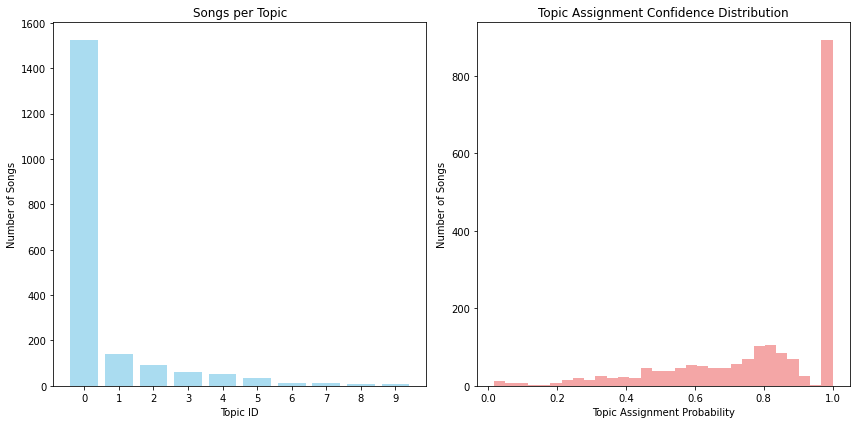

📊 Summary Statistics:
   Total unique topics: 10
   Average songs per topic: 194.5
   Largest topic size: 1526
   Smallest topic size: 7

📈 Gini Coefficient for Topic Distribution: 0.8139


In [81]:
# ===== TOPIC ANALYSIS AND VISUALIZATION =====

print("📊 Analyzing discovered topics...")

# Get detailed topic information
topic_info = topic_model.get_topic_info()
print(f"Topic Info Shape: {topic_info.shape}")

# Analyze topic distribution
topic_counts = df['topic'].value_counts().sort_index()
print(f"\n🏷️ Topic Distribution:")
print(f"   Valid topics: {len(topic_counts[topic_counts.index != -1])}")
print(f"   Outliers (topic -1): {topic_counts.get(-1, 0)}")

# Show top topics with their representative words
print(f"\n🔝 Top 10 Topics by Size:")
valid_topics = topic_info[topic_info['Topic'] != -1].head(10)

for _, row in valid_topics.iterrows():
    topic_id = row['Topic']
    count = row['Count']
    # Get clean topic words (remove scores)
    topic_words = [word.split('_')[0] for word in row['Representation'][:8]]
    print(f"   Topic {topic_id:2d} ({count:4d} songs): {', '.join(topic_words)}")
    print(f"      TopicLabel_OpenAI: {row['OpenAI']}")
    
    # Show sample songs for this topic
    sample_songs = df[df['topic'] == topic_id].head(3)
    for _, song in sample_songs.iterrows():
        print(f"      • {song['artist']} - {song['song_title']}")
    print()

# Visualize topic sizes
plt.figure(figsize=(12, 6))
valid_topic_counts = topic_counts[topic_counts.index != -1]

plt.subplot(1, 2, 1)
plt.bar(range(len(valid_topic_counts)), valid_topic_counts.values, color='skyblue', alpha=0.7)
plt.xlabel('Topic ID')
plt.ylabel('Number of Songs')
plt.title('Songs per Topic')
plt.xticks(range(len(valid_topic_counts)), valid_topic_counts.index)

plt.subplot(1, 2, 2)
plt.hist(df[df['topic'] != -1]['topic_probability'], bins=30, color='lightcoral', alpha=0.7)
plt.xlabel('Topic Assignment Probability')
plt.ylabel('Number of Songs')
plt.title('Topic Assignment Confidence Distribution')

plt.tight_layout()
plt.show()

print(f"📊 Summary Statistics:")
print(f"   Total unique topics: {len(valid_topic_counts)}")
print(f"   Average songs per topic: {valid_topic_counts.mean():.1f}")
print(f"   Largest topic size: {valid_topic_counts.max()}")
print(f"   Smallest topic size: {valid_topic_counts.min()}")


def gini_coefficient(x):
    """Calculate Gini coefficient for inequality measurement"""
    sorted_x = np.sort(x)
    n = len(x)
    cumsum = np.cumsum(sorted_x)
    return (n + 1 - 2 * np.sum(cumsum) / cumsum[-1]) / n

topic_counts =topic_model.get_topic_info()['Count'].tolist()
gini = gini_coefficient(topic_counts)
print(f"\n📈 Gini Coefficient for Topic Distribution: {gini:.4}")



In [83]:
topic_counts =topic_model.get_topic_info()['Count'].tolist()
sorted_counts = np.sort(topic_counts)
cum_sum = np.cumsum(sorted_counts)
print(cum_sum)

[   7   15   27   41   74  124  184  277  419 1945 5946]


In [62]:
# ===== LLM-ASSISTED TOPIC LABELING WITH LANGCHAIN + OPENAI =====

def generate_topic_labels_with_llm(topic_model: BERTopic, max_topics=20):
    """
    Generate human-readable topic labels using LangChain + OpenAI GPT
    """
    print("🤖 Generating human-readable topic labels with LLM...")
    
    # Check if OpenAI API key is set
    if not os.getenv("OPENAI_API_KEY"):
        print("⚠️ OpenAI API key not found. Please set OPENAI_API_KEY environment variable.")
        print("   Example: os.environ['OPENAI_API_KEY'] = 'your-api-key-here'")
        raise ValueError("OpenAI API key not set")
    
    # Initialize LangChain OpenAI client
    try:
        llm = ChatOpenAI(
            model="gpt-4o",
            temperature=0.0,  # Set to 0 for consistent outputs
            max_tokens=80,    # Reduced for more concise labels
            api_key=os.getenv("OPENAI_API_KEY"),
            seed=42,          # For reproducible outputs
            top_p=1.0, 
        )
        print("   ✅ Connected to OpenAI GPT-4o")
    except Exception as e:
        print(f"   ❌ Failed to connect to OpenAI: {e}")
        raise e
    
    # Create prompt template for topic labeling
    prompt_template = PromptTemplate.from_template(
        """You are a music expert analyzing song lyrics topics. 
        
        Here are the top 10 most representative words for a music topic:
        {topic_words}
        
        Based on these words, please provide:
        1. A concise, human-readable topic label (2-4 words)
        2. A brief explanation of why this label fits
        
        Topic Label:"""
    )
    
    topic_labels = {}
    topic_info = topic_model.get_topic_info()
    
    # Process top topics (excluding outliers)
    valid_topics = topic_info[topic_info['Topic'] != -1].head(max_topics)
    
    print(f"   Processing {len(valid_topics)} topics...")
    
    for i, row in valid_topics.iterrows():
        topic_id = row['Topic']
        topic_words = [word.split('_')[0] for word in row['Representation'][:20]]
        
        try:
            # Create prompt
            prompt = prompt_template.format(topic_words=", ".join(topic_words))
            
            # Get LLM response
            messages = [
                SystemMessage(content="You are a helpful music expert that creates concise topic labels."),
                HumanMessage(content=prompt)
            ]
            
            response = llm(messages)
            
            # Extract the label (first line of response)
            label = response.content.strip().split('\n')[0]
            
            # Clean up the label
            if label.startswith("Topic Label:"):
                label = label.replace("Topic Label:", "").strip()
            
            # Ensure label is not too long
            if len(label) > 50:
                label = label[:47] + "..."
            
            topic_labels[topic_id] = {
                'label': label,
                'words': topic_words,
                'confidence': 'llm_generated',
                'raw_response': response.content
            }
            
            print(f"   Topic {topic_id:2d}: '{label}'\n")
            print(f"      Representative words: {', '.join(topic_words[:20])}")
            
        except Exception as e:
            print(f"   ❌ Failed to generate label for topic {topic_id}: {e}")
            # Fallback to manual labeling for this topic
            topic_labels[topic_id] = {
                'label': f"Topic {topic_id}",
                'words': topic_words,
                'confidence': 'fallback',
                'raw_response': str(e)
            }
            raise e
    
    return topic_labels


# Generate topic labels using LLM
topic_labels = generate_topic_labels_with_llm(topic_model, max_topics=15)

print(f"\n✅ Generated labels for {len(topic_labels)} topics")

# Show summary of labeling methods used
llm_labels = sum(1 for label in topic_labels.values() if label['confidence'] == 'llm_generated')
fallback_labels = sum(1 for label in topic_labels.values() if label['confidence'] in ['fallback', 'rule_based'])

print(f"\n📊 Labeling Summary:")
print(f"   LLM-generated labels: {llm_labels}")
print(f"   Rule-based labels: {fallback_labels}")

if llm_labels > 0:
    print(f"\n🎯 LLM-generated topic labels are ready!")
    print(f"   To improve results, consider adjusting the prompt template or using GPT-4")
else:
    print(f"\n💡 To use LLM labeling, set your OpenAI API key:")
    print(f"   os.environ['OPENAI_API_KEY'] = 'your-api-key-here'")

🤖 Generating human-readable topic labels with LLM...
   ✅ Connected to OpenAI GPT-4o
   Processing 10 topics...
   Topic  0: 'Romantic Pop Anthem'

      Representative words: oh, love, know, yeah, don, just, like, ooh, baby, ll, la, let, got, ve, time, make, want, way, girl, wanna
   Topic  1: 'Hip-Hop Bravado'

      Representative words: nigga, bitch, yeah, fuck, like, got, ain, niggas, dick, don, know, shit, bubble, cause, just, man, ma, money, ass, new
   Topic  2: 'Love and Relationships'

      Representative words: que, el, te, la, che, tu, se, en, si, yo, non, mi, il, lo, una, di, tú, por, es, amor
   Topic  3: 'Christian Worship Music'

      Representative words: jesus, lord, holy, praise, god, hallelujah, amazing, yes, forever, oh, king, worship, glory, sing, yeah, trust, faithful, ho, let, lifted
   Topic  4: 'K-Pop Energetic Expressions'

      Representative words: oh, yeah, na, 너무, peek, du, gee, 다시, 내가, eh, ooh, 거야, ah, 너의, 너를, 없는, run, 나를, 말해봐, 없어
   Topic  5: 'Revolu

In [63]:
# ===== TOPIC DISTRIBUTION EXTRACTION =====

def get_song_topic_distribution(topic_model, documents, topics, probabilities):
    """
    Extract topic distributions for each song
    BERTopic assigns each document to one topic, but we can get soft distributions
    """
    print("📊 Extracting topic distributions for songs...")
    
    num_topics = len(set(topics)) - (1 if -1 in topics else 0)  # Exclude outlier topic
    # num_topics = len(set(topics))
    topic_distributions = []
    
    # For each document, create a distribution vector
    for i, (topic, prob_array) in enumerate(zip(topics, probabilities)):
        if topic == -1:  # Outlier documents
            # Create uniform low-confidence distribution
            distribution = np.ones(num_topics) / num_topics * 0.1
        else:
            # Use the probability distribution from BERTopic
            if prob_array is not None:
                # Normalize and ensure it sums to 1
                distribution = prob_array[:num_topics]
                distribution = distribution / distribution.sum()
            else:
                # Fallback: create one-hot distribution
                distribution = np.zeros(num_topics)
                if topic < num_topics:
                    distribution[topic] = 1.0
        
        topic_distributions.append(distribution)
        
        if (i + 1) % 500 == 0:
            print(f"   Processed {i + 1}/{len(documents)} distributions")
    
    print(f"✅ Generated topic distributions: {len(topic_distributions)} songs × {num_topics} topics")
    return np.array(topic_distributions)

# Extract topic distributions
song_topic_distributions = get_song_topic_distribution(
    topic_model, documents, topics, probabilities
)

# Add to dataframe for easier analysis
df['topic_distribution'] = list(song_topic_distributions)

print(f"📊 Topic Distribution Statistics:")
print(f"   Shape: {song_topic_distributions.shape}")
print(f"   Average entropy: {np.mean([-np.sum(dist * np.log(dist + 1e-10)) for dist in song_topic_distributions]):.3f}")
print(f"   Max probability per song (avg): {np.mean(song_topic_distributions.max(axis=1)):.3f}")

# Show sample distributions
print(f"\n📝 Sample topic distributions:")
for i in range(3):
    song = df.iloc[i]
    dist = song_topic_distributions[i]
    top_topics = np.argsort(dist)[-3:][::-1]  # Top 3 topics
    
    print(f"   {song['artist']} - {song['song_title']}")
    for topic_idx in top_topics:
        prob = dist[topic_idx]
        label = topic_labels.get(topic_idx, {}).get('label', f'Topic {topic_idx}')
        print(f"      {label}: {prob:.3f}")
    print()

📊 Extracting topic distributions for songs...
   Processed 500/5946 distributions
   Processed 1000/5946 distributions
   Processed 1500/5946 distributions
   Processed 2000/5946 distributions
   Processed 2500/5946 distributions
   Processed 3000/5946 distributions
   Processed 3500/5946 distributions
   Processed 4000/5946 distributions
   Processed 4500/5946 distributions
   Processed 5000/5946 distributions
   Processed 5500/5946 distributions
✅ Generated topic distributions: 5946 songs × 10 topics
📊 Topic Distribution Statistics:
   Shape: (5946, 10)
   Average entropy: 0.415
   Max probability per song (avg): 0.305

📝 Sample topic distributions:
   21 Savage - Bank Account
      Global Unity and Growth: 0.010
      Electric Dance Vibes: 0.010
      British Farewell Ballad: 0.010

   21 Savage - Ghostface Killers
      Hip-Hop Bravado: 1.000
      Romantic Pop Anthem: 0.000
      Revolution and Rebellion: 0.000

   21 Savage - Glock in My Lap
      Global Unity and Growth: 0.010
 

In [64]:
# ===== ARTIST-LEVEL AGGREGATION =====

def aggregate_artist_topic_distributions(df, song_topic_distributions, method='weighted_average'):
    """
    Aggregate song-level topic distributions to artist level
    
    Methods:
    - 'average': Simple average of all songs
    - 'weighted_average': Weight by topic confidence
    - 'recent': Weight more recent songs higher (if date available)
    """
    print(f"🎤 Aggregating topic distributions to artist level...")
    print(f"   Method: {method}")
    
    artist_distributions = {}
    artist_info = {}
    
    for artist in df['artist'].unique():
        artist_songs = df[df['artist'] == artist]
        song_indices = artist_songs.index.tolist()
        
        # Get topic distributions for this artist's songs
        artist_song_distributions = song_topic_distributions[song_indices]
        
        if method == 'average':
            # Simple average
            artist_dist = np.mean(artist_song_distributions, axis=0)
            
        elif method == 'weighted_average':
            # Weight by topic confidence (max probability per song)
            weights = np.max(artist_song_distributions, axis=1)
            weights = weights / weights.sum()  # Normalize weights
            artist_dist = np.average(artist_song_distributions, axis=0, weights=weights)
            
        else:  # fallback to average
            artist_dist = np.mean(artist_song_distributions, axis=0)
        
        # Normalize to ensure it's a proper probability distribution
        artist_dist = artist_dist / artist_dist.sum()
        
        artist_distributions[artist] = artist_dist
        artist_info[artist] = {
            'num_songs': len(artist_songs),
            'avg_confidence': np.mean([np.max(dist) for dist in artist_song_distributions]),
            'top_topics': np.argsort(artist_dist)[-3:][::-1],  # Top 3 topics
            'sample_songs': artist_songs['song_title'].head(3).tolist()
        }
    
    print(f"✅ Aggregated distributions for {len(artist_distributions)} artists")
    return artist_distributions, artist_info

# Aggregate to artist level
artist_topic_distributions, artist_info = aggregate_artist_topic_distributions(
    df, song_topic_distributions, method='weighted_average'
)

print(f"\n📊 Artist-Level Statistics:")
print(f"   Total artists: {len(artist_topic_distributions)}")
print(f"   Average songs per artist: {np.mean([info['num_songs'] for info in artist_info.values()]):.1f}")
print(f"   Artists with 1 song: {sum(1 for info in artist_info.values() if info['num_songs'] == 1)}")
print(f"   Artists with 5+ songs: {sum(1 for info in artist_info.values() if info['num_songs'] >= 5)}")

# Show sample artist profiles
print(f"\n🎤 Sample Artist Topic Profiles:")
sample_artists = list(artist_info.keys())[:5]

for artist in sample_artists:
    dist = artist_topic_distributions[artist]
    info = artist_info[artist]
    
    print(f"\n   {artist} ({info['num_songs']} songs):")
    
    # Show top 3 topics
    for i, topic_idx in enumerate(info['top_topics']):
        prob = dist[topic_idx]
        label = topic_labels.get(topic_idx, {}).get('label', f'Topic {topic_idx}')
        print(f"      {i+1}. {label}: {prob:.3f}")
    
    # Show sample songs
    print(f"      Sample songs: {', '.join(info['sample_songs'])}")

🎤 Aggregating topic distributions to artist level...
   Method: weighted_average
✅ Aggregated distributions for 600 artists

📊 Artist-Level Statistics:
   Total artists: 600
   Average songs per artist: 9.9
   Artists with 1 song: 2
   Artists with 5+ songs: 596

🎤 Sample Artist Topic Profiles:

   21 Savage (10 songs):
      1. Hip-Hop Bravado: 0.999
      2. Global Unity and Growth: 0.000
      3. Electric Dance Vibes: 0.000
      Sample songs: Bank Account, Ghostface Killers, Glock in My Lap

   702 (10 songs):
      1. Romantic Pop Anthem: 0.956
      2. Hip-Hop Bravado: 0.023
      3. Revolution and Rebellion: 0.005
      Sample songs: Come & Knock On My Door, Cousin Skeeter, Get It Together

   A Day to Remember (10 songs):
      1. Romantic Pop Anthem: 0.949
      2. Hip-Hop Bravado: 0.027
      3. Christian Worship Music: 0.006
      Sample songs: All I Want, All Signs Point to Lauderdale, Have Faith in Me

   AC/DC (10 songs):
      1. Romantic Pop Anthem: 0.881
      2. Hip-H

🔬 Starting Simplified Topic Quality Analysis...
📊 TOPIC QUALITY ANALYSIS (C_V Coherence + Vocabulary Diversity)
📊 Analysis Overview:
   • Number of valid topics: 10
   • Total documents: 5946
   • Documents with topic assignments: 1945

🔄 Preparing documents for coherence analysis...
   ✅ Processed 5946 documents
   ✅ Dictionary size: 73322 unique words

🔍 Extracting topic representations...
   ✅ Extracted words for 10 topics

1️⃣ C_V COHERENCE ANALYSIS

🔍 Calculating C_V coherence...
   ✅ C_V Coherence (average): 0.4070
   🎯 Coherence Quality: Excellent (>0.3 is good)

🏆 Most Coherent Topics:
   1. Topic 2: 0.7210 - Love and Relationships
      Words: que, el, te, la, che
   2. Topic 3: 0.5552 - Christian Worship Music
      Words: jesus, lord, holy, praise, god
   3. Topic 1: 0.4598 - Hip-Hop Bravado
      Words: nigga, bitch, yeah, fuck, like

🔻 Least Coherent Topics:
   1. Topic 7: 0.2648 - British Farewell Ballad
   2. Topic 4: 0.2029 - K-Pop Energetic Expressions

2️⃣ VOCABULARY 

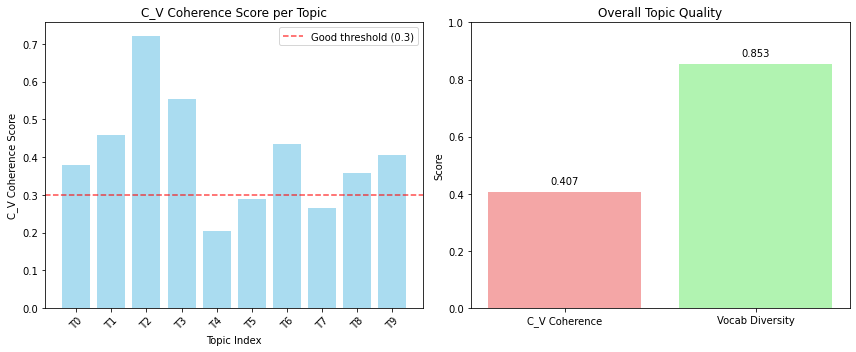

✅ Visualization complete!

🎊 ANALYSIS COMPLETE!
📈 Key Results:
   • C_V Coherence: 0.4070
   • Vocabulary Diversity: 0.8533

💾 Results stored in topic_model.coherence_score_ and topic_model.vocab_diversity_


In [65]:
# ===== SIMPLIFIED TOPIC COHERENCE AND DIVERSITY ANALYSIS =====

import gensim
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary
import gc


def calculate_cv_coherence_and_vocab_diversity(topic_model, documents, topics, topic_labels=None):
    """
    Calculate C_V coherence and vocabulary diversity metrics only
    """
    print("📊 TOPIC QUALITY ANALYSIS (C_V Coherence + Vocabulary Diversity)")
    print("=" * 70)

    # Get valid topics (exclude outliers)
    valid_topic_ids = [t for t in set(topics) if t != -1]
    num_valid_topics = len(valid_topic_ids)

    print(f"📊 Analysis Overview:")
    print(f"   • Number of valid topics: {num_valid_topics}")
    print(f"   • Total documents: {len(documents)}")
    print(
        f"   • Documents with topic assignments: {len([t for t in topics if t != -1])}")

    # Prepare documents for Gensim
    print(f"\n🔄 Preparing documents for coherence analysis...")

    # Tokenize documents
    tokenized_docs = []
    for doc in documents:
        if doc and len(doc.strip()) > 0:
            tokens = [word.lower() for word in doc.split() if len(word) > 2]
            tokenized_docs.append(tokens)
        else:
            tokenized_docs.append([])

    # Create dictionary for Gensim
    dictionary = Dictionary(tokenized_docs)

    print(f"   ✅ Processed {len(tokenized_docs)} documents")
    print(f"   ✅ Dictionary size: {len(dictionary)} unique words")

    # Extract topic words from BERTopic
    print(f"\n🔍 Extracting topic representations...")

    topic_words = []
    topic_info_dict = {}

    for topic_id in sorted(valid_topic_ids):
        topic_repr = topic_model.get_topic(topic_id)
        if topic_repr:
            words = [word for word, _ in topic_repr[:15]]  # Top 15 words
            topic_words.append(words)

            topic_info_dict[topic_id] = {
                'words': words,
                'label': topic_labels.get(topic_id, {}).get('label', f'Topic {topic_id}') if topic_labels else f'Topic {topic_id}',
                'size': len([t for t in topics if t == topic_id])
            }
        else:
            topic_words.append([])

    print(f"   ✅ Extracted words for {len(topic_words)} topics")

    # =============================================================
    # 1️⃣ C_V COHERENCE ANALYSIS
    # =============================================================
    print(f"\n" + "="*50)
    print(f"1️⃣ C_V COHERENCE ANALYSIS")
    print(f"=" * 50)

    print(f"\n🔍 Calculating C_V coherence...")
    try:
        cm_cv = CoherenceModel(
            topics=topic_words,
            texts=tokenized_docs,
            dictionary=dictionary,
            coherence='c_v',
            processes=1
        )
        cv_coherence = cm_cv.get_coherence()
        cv_per_topic = cm_cv.get_coherence_per_topic()

        print(f"   ✅ C_V Coherence (average): {cv_coherence:.4f}")

        # Clean up
        del cm_cv
        gc.collect()

    except Exception as e:
        print(f"   ❌ Error calculating C_V coherence: {e}")
        cv_coherence = 0.0
        cv_per_topic = [0.0] * len(topic_words)

    # Show coherence quality assessment
    if cv_coherence > 0.4:
        coherence_rating = "Excellent"
    elif cv_coherence > 0.3:
        coherence_rating = "Good"
    elif cv_coherence > 0.2:
        coherence_rating = "Fair"
    else:
        coherence_rating = "Poor"

    print(f"   🎯 Coherence Quality: {coherence_rating} (>0.3 is good)")

    # Show top and bottom performing topics
    if cv_per_topic and len(cv_per_topic) > 0:
        print(f"\n🏆 Most Coherent Topics:")
        topic_coherence_pairs = list(zip(valid_topic_ids, cv_per_topic))
        topic_coherence_pairs.sort(key=lambda x: x[1], reverse=True)

        for i, (topic_id, score) in enumerate(topic_coherence_pairs[:3]):
            label = topic_info_dict[topic_id]['label']
            words = ', '.join(topic_info_dict[topic_id]['words'][:5])
            print(f"   {i+1}. Topic {topic_id}: {score:.4f} - {label}")
            print(f"      Words: {words}")

        print(f"\n🔻 Least Coherent Topics:")
        for i, (topic_id, score) in enumerate(topic_coherence_pairs[-2:]):
            label = topic_info_dict[topic_id]['label']
            words = ', '.join(topic_info_dict[topic_id]['words'][:5])
            print(f"   {i+1}. Topic {topic_id}: {score:.4f} - {label}")

    # =============================================================
    # 2️⃣ VOCABULARY DIVERSITY ANALYSIS
    # =============================================================
    print(f"\n" + "="*50)
    print(f"2️⃣ VOCABULARY DIVERSITY ANALYSIS")
    print(f"=" * 50)

    print(f"\n🔍 Calculating vocabulary diversity...")
    all_topic_words = set()
    total_topic_words = 0

    for words in topic_words:
        all_topic_words.update(words)
        total_topic_words += len(words)

    vocab_diversity = len(all_topic_words) / \
        total_topic_words if total_topic_words > 0 else 0

    print(f"   Total unique words across topics: {len(all_topic_words)}")
    print(f"   Total word slots: {total_topic_words}")
    print(f"   Vocabulary Diversity: {vocab_diversity:.4f}")

    # Diversity quality assessment
    if vocab_diversity > 0.8:
        diversity_rating = "Excellent"
    elif vocab_diversity > 0.6:
        diversity_rating = "Good"
    elif vocab_diversity > 0.4:
        diversity_rating = "Fair"
    else:
        diversity_rating = "Poor"

    print(f"   🌈 Diversity Quality: {diversity_rating} (>0.6 is good)")

    # =============================================================
    # 3️⃣ OVERALL ASSESSMENT & RECOMMENDATIONS
    # =============================================================
    print(f"\n" + "="*50)
    print(f"3️⃣ OVERALL QUALITY ASSESSMENT")
    print(f"=" * 50)

    print(f"\n📊 Quality Summary:")
    print(f"   🎯 C_V Coherence: {coherence_rating} ({cv_coherence:.3f})")
    print(
        f"   🌈 Vocabulary Diversity: {diversity_rating} ({vocab_diversity:.3f})")

    print(f"\n💡 Recommendations:")
    if cv_coherence < 0.3:
        print(f"   • Low coherence detected. Consider:")
        print(f"     - Adjusting HDBSCAN min_cluster_size")
        print(f"     - Different preprocessing or embedding model")

    if vocab_diversity < 0.6:
        print(f"   • Low diversity detected. Consider:")
        print(f"     - Increasing number of topics")
        print(f"     - Different clustering parameters")

    if cv_coherence >= 0.3 and vocab_diversity >= 0.6:
        print(f"   ✅ Good topic quality! No major improvements needed.")

    # Store results
    results = {
        'c_v_coherence': cv_coherence,
        'c_v_per_topic': cv_per_topic,
        'vocab_diversity': vocab_diversity,
        'topic_info': topic_info_dict
    }

    print(f"\n✅ Analysis complete!")
    return results

# Visualize results


def visualize_topic_quality(results, topics):
    """
    Create simple visualizations for coherence and diversity
    """
    print(f"\n📊 VISUALIZATION")
    print("=" * 30)

    cv_coherence = results['c_v_coherence']
    vocab_diversity = results['vocab_diversity']
    cv_per_topic = results['c_v_per_topic']

    if cv_per_topic and len(cv_per_topic) > 0:
        plt.figure(figsize=(12, 5))

        # Plot 1: Coherence scores per topic
        plt.subplot(1, 2, 1)
        valid_topic_ids = [t for t in set(topics) if t != -1]

        bars = plt.bar(range(len(cv_per_topic)), cv_per_topic,
                       color='skyblue', alpha=0.7)
        plt.xlabel('Topic Index')
        plt.ylabel('C_V Coherence Score')
        plt.title('C_V Coherence Score per Topic')
        plt.xticks(range(len(cv_per_topic)), [
                   f'T{tid}' for tid in sorted(valid_topic_ids)])
        plt.xticks(rotation=45)

        # Add threshold line
        plt.axhline(y=0.3, color='red', linestyle='--',
                    alpha=0.7, label='Good threshold (0.3)')
        plt.legend()

        # Plot 2: Overall quality scores
        plt.subplot(1, 2, 2)
        metrics = ['C_V Coherence', 'Vocab Diversity']
        scores = [cv_coherence, vocab_diversity]
        colors = ['lightcoral', 'lightgreen']

        bars = plt.bar(metrics, scores, color=colors, alpha=0.7)
        plt.ylabel('Score')
        plt.title('Overall Topic Quality')
        plt.ylim(0, 1)

        # Add value labels
        for bar, score in zip(bars, scores):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                     f'{score:.3f}', ha='center', va='bottom')

        plt.tight_layout()
        plt.show()
        print("✅ Visualization complete!")


# Run the simplified analysis
print("🔬 Starting Simplified Topic Quality Analysis...")
results = calculate_cv_coherence_and_vocab_diversity(
    topic_model, documents, topics, topic_labels
)

# Create visualizations
visualize_topic_quality(results, topics)

print(f"\n🎊 ANALYSIS COMPLETE!")
print(f"📈 Key Results:")
print(f"   • C_V Coherence: {results['c_v_coherence']:.4f}")
print(f"   • Vocabulary Diversity: {results['vocab_diversity']:.4f}")

# Store results in topic model
topic_model.coherence_score_ = results['c_v_coherence']
topic_model.vocab_diversity_ = results['vocab_diversity']
print(f"\n💾 Results stored in topic_model.coherence_score_ and topic_model.vocab_diversity_")

In [66]:
# ===== SIMILARITY CALCULATION FUNCTIONS =====

def calculate_cosine_similarity(dist1, dist2):
    """Calculate cosine similarity between two topic distributions"""
    return 1 - cosine(dist1, dist2)

def calculate_jensen_shannon_divergence(dist1, dist2):
    """Calculate Jensen-Shannon divergence between two distributions"""
    # Ensure no zero probabilities
    dist1 = dist1 + 1e-10
    dist2 = dist2 + 1e-10
    
    # Normalize
    dist1 = dist1 / dist1.sum()
    dist2 = dist2 / dist2.sum()
    
    # Calculate JS divergence
    m = 0.5 * (dist1 + dist2)
    js_div = 0.5 * (np.sum(dist1 * np.log(dist1 / m)) + np.sum(dist2 * np.log(dist2 / m)))
    
    # Convert to similarity (0 = identical, 1 = completely different)
    return 1 - js_div

def find_similar_artists(query_artist, artist_distributions, artist_info, 
                        metric='cosine', top_k=10, exclude_query=True):
    """
    Find artists similar to the query artist based on topic distributions
    """
    if query_artist not in artist_distributions:
        print(f"❌ Artist '{query_artist}' not found in database")
        return []
    
    query_dist = artist_distributions[query_artist]
    similarities = []
    
    for artist, dist in artist_distributions.items():
        # Skip the query artist itself
        if exclude_query and artist == query_artist:
            continue
            
        if metric == 'cosine':
            similarity = calculate_cosine_similarity(query_dist, dist)
        elif metric == 'jensen_shannon':
            similarity = calculate_jensen_shannon_divergence(query_dist, dist)
        else:
            similarity = calculate_cosine_similarity(query_dist, dist)  # default
        
        similarities.append({
            'artist': artist,
            'similarity': similarity,
            'num_songs': artist_info[artist]['num_songs'],
            'top_topics': artist_info[artist]['top_topics']
        })
    
    # Sort by similarity (highest first)
    similarities.sort(key=lambda x: x['similarity'], reverse=True)
    
    return similarities[:top_k]

# Test similarity calculation
print("🔍 Testing artist similarity calculation...")

# Get a sample artist with multiple songs
multi_song_artists = [artist for artist, info in artist_info.items() if info['num_songs'] >= 3]
test_artist = multi_song_artists[0] if multi_song_artists else list(artist_info.keys())[0]

print(f"🎤 Finding artists similar to: {test_artist}")
print(f"   ({artist_info[test_artist]['num_songs']} songs)")

# Show query artist's top topics
query_dist = artist_topic_distributions[test_artist]
top_topics = artist_info[test_artist]['top_topics']
print(f"   Top themes:")
for i, topic_idx in enumerate(top_topics):
    prob = query_dist[topic_idx]
    label = topic_labels.get(topic_idx, {}).get('label', f'Topic {topic_idx}')
    print(f"      {i+1}. {label}: {prob:.3f}")

# Find similar artists
similar_artists = find_similar_artists(
    test_artist, artist_topic_distributions, artist_info, 
    metric='cosine', top_k=8
)

print(f"\n🎯 Most similar artists:")
for i, result in enumerate(similar_artists, 1):
    artist_dist = artist_topic_distributions[result['artist']]
    top_topic_idx = result['top_topics'][0]
    top_topic_label = topic_labels.get(top_topic_idx, {}).get('label', f'Topic {top_topic_idx}')
    
    print(f"   {i}. {result['artist']} (similarity: {result['similarity']:.3f})")
    print(f"      {result['num_songs']} songs, main theme: {top_topic_label}")

🔍 Testing artist similarity calculation...
🎤 Finding artists similar to: 21 Savage
   (10 songs)
   Top themes:
      1. Hip-Hop Bravado: 0.999
      2. Global Unity and Growth: 0.000
      3. Electric Dance Vibes: 0.000

🎯 Most similar artists:
   1. Dr. Dre (similarity: 1.000)
      10 songs, main theme: Hip-Hop Bravado
   2. N.W.A. (similarity: 1.000)
      10 songs, main theme: Hip-Hop Bravado
   3. Ice Cube (similarity: 1.000)
      10 songs, main theme: Hip-Hop Bravado
   4. Rico Nasty (similarity: 1.000)
      10 songs, main theme: Hip-Hop Bravado
   5. Deadmau5 (similarity: 1.000)
      10 songs, main theme: Hip-Hop Bravado
   6. Kendrick Lamar (similarity: 1.000)
      10 songs, main theme: Hip-Hop Bravado
   7. Mac Miller (similarity: 1.000)
      10 songs, main theme: Hip-Hop Bravado
   8. Nas (similarity: 1.000)
      10 songs, main theme: Hip-Hop Bravado


In [67]:
# ===== DIVERSITY-AWARE RECOMMENDATIONS (MMR) =====

def maximal_marginal_relevance(query_dist, candidate_distributions, candidate_info, 
                              lambda_param=0.7, top_k=10):
    """
    Implement Maximal Marginal Relevance for diverse recommendations
    
    Args:
        query_dist: Query artist's topic distribution
        candidate_distributions: Dict of candidate artist distributions
        candidate_info: Dict of candidate artist info
        lambda_param: Trade-off between relevance (1.0) and diversity (0.0)
        top_k: Number of recommendations to return
    
    Returns:
        List of diversified recommendations
    """
    print(f"🎯 Applying MMR for diverse recommendations (λ={lambda_param})...")
    
    # Calculate initial relevance scores
    relevance_scores = {}
    for artist, dist in candidate_distributions.items():
        relevance_scores[artist] = calculate_cosine_similarity(query_dist, dist)
    
    # MMR algorithm
    selected = []
    remaining = list(candidate_distributions.keys())
    
    # First selection: most relevant
    if remaining:
        first_artist = max(remaining, key=lambda x: relevance_scores[x])
        selected.append(first_artist)
        remaining.remove(first_artist)
    
    # Subsequent selections: balance relevance and diversity
    while len(selected) < top_k and remaining:
        mmr_scores = {}
        
        for candidate in remaining:
            # Relevance component
            relevance = relevance_scores[candidate]
            
            # Diversity component (maximum similarity to any selected item)
            max_similarity = 0
            for selected_artist in selected:
                similarity = calculate_cosine_similarity(
                    candidate_distributions[candidate],
                    candidate_distributions[selected_artist]
                )
                max_similarity = max(max_similarity, similarity)
            
            # MMR score
            mmr_score = lambda_param * relevance - (1 - lambda_param) * max_similarity
            mmr_scores[candidate] = mmr_score
        
        # Select candidate with highest MMR score
        next_artist = max(remaining, key=lambda x: mmr_scores[x])
        selected.append(next_artist)
        remaining.remove(next_artist)
    
    # Format results
    recommendations = []
    for i, artist in enumerate(selected):
        recommendations.append({
            'rank': i + 1,
            'artist': artist,
            'relevance': relevance_scores[artist],
            'num_songs': candidate_info[artist]['num_songs'],
            'top_topics': candidate_info[artist]['top_topics'],
            'sample_songs': candidate_info[artist]['sample_songs']
        })
    
    return recommendations

def compare_recommendation_strategies(query_artist, artist_distributions, artist_info, top_k=8):
    """
    Compare different recommendation strategies
    """
    print(f"⚖️ Comparing recommendation strategies for: {query_artist}")
    
    if query_artist not in artist_distributions:
        print(f"❌ Artist not found: {query_artist}")
        return
    
    query_dist = artist_distributions[query_artist]
    
    # Exclude query artist from candidates
    candidate_distributions = {k: v for k, v in artist_distributions.items() if k != query_artist}
    candidate_info = {k: v for k, v in artist_info.items() if k != query_artist}
    
    # Strategy 1: Pure similarity (no diversity)
    print(f"\n📊 Strategy 1: Pure Similarity (λ=1.0)")
    pure_similarity = find_similar_artists(
        query_artist, artist_distributions, artist_info, 
        metric='cosine', top_k=top_k
    )
    
    for i, rec in enumerate(pure_similarity, 1):
        top_topic_label = topic_labels.get(rec['top_topics'][0], {}).get('label', f"Topic {rec['top_topics'][0]}")
        print(f"   {i}. {rec['artist']} ({rec['similarity']:.3f}) - {top_topic_label}")
    
    # Strategy 2: Balanced MMR
    print(f"\n🎯 Strategy 2: Balanced MMR (λ=0.7)")
    balanced_mmr = maximal_marginal_relevance(
        query_dist, candidate_distributions, candidate_info,
        lambda_param=0.7, top_k=top_k
    )
    
    for rec in balanced_mmr:
        top_topic_label = topic_labels.get(rec['top_topics'][0], {}).get('label', f"Topic {rec['top_topics'][0]}")
        print(f"   {rec['rank']}. {rec['artist']} ({rec['relevance']:.3f}) - {top_topic_label}")
    
    # Strategy 3: High diversity MMR
    print(f"\n🌈 Strategy 3: High Diversity MMR (λ=0.4)")
    diverse_mmr = maximal_marginal_relevance(
        query_dist, candidate_distributions, candidate_info,
        lambda_param=0.4, top_k=top_k
    )
    
    for rec in diverse_mmr:
        top_topic_label = topic_labels.get(rec['top_topics'][0], {}).get('label', f"Topic {rec['top_topics'][0]}")
        print(f"   {rec['rank']}. {rec['artist']} ({rec['relevance']:.3f}) - {top_topic_label}")
    
    return {
        'pure_similarity': pure_similarity,
        'balanced_mmr': balanced_mmr,
        'diverse_mmr': diverse_mmr
    }

# Test different recommendation strategies
test_artist = multi_song_artists[0] if multi_song_artists else list(artist_info.keys())[0]
recommendation_comparison = compare_recommendation_strategies(
    test_artist, artist_topic_distributions, artist_info, top_k=6
)

⚖️ Comparing recommendation strategies for: 21 Savage

📊 Strategy 1: Pure Similarity (λ=1.0)
   1. Dr. Dre (1.000) - Hip-Hop Bravado
   2. N.W.A. (1.000) - Hip-Hop Bravado
   3. Ice Cube (1.000) - Hip-Hop Bravado
   4. Rico Nasty (1.000) - Hip-Hop Bravado
   5. Deadmau5 (1.000) - Hip-Hop Bravado
   6. Kendrick Lamar (1.000) - Hip-Hop Bravado

🎯 Strategy 2: Balanced MMR (λ=0.7)
🎯 Applying MMR for diverse recommendations (λ=0.7)...
   1. Dr. Dre (1.000) - Hip-Hop Bravado
   2. N.W.A. (1.000) - Hip-Hop Bravado
   3. Ice Cube (1.000) - Hip-Hop Bravado
   4. Rico Nasty (1.000) - Hip-Hop Bravado
   5. Deadmau5 (1.000) - Hip-Hop Bravado
   6. Kendrick Lamar (1.000) - Hip-Hop Bravado

🌈 Strategy 3: High Diversity MMR (λ=0.4)
🎯 Applying MMR for diverse recommendations (λ=0.4)...
   1. Dr. Dre (1.000) - Hip-Hop Bravado
   2. David Guetta (0.000) - Romantic Pop Anthem
   3. Il Divo (0.000) - Love and Relationships
   4. BLACKPINK (0.001) - K-Pop Energetic Expressions
   5. The O'Jays (0.011) - Du

In [68]:
# ===== EVALUATION METRICS =====

def calculate_intra_list_diversity(recommendations, artist_distributions):
    """
    Calculate intra-list diversity (average pairwise dissimilarity)
    Lower values = more similar recommendations (less diverse)
    Higher values = more diverse recommendations
    """
    if len(recommendations) < 2:
        return 0.0
    
    artists = [rec['artist'] for rec in recommendations]
    similarities = []
    
    for i in range(len(artists)):
        for j in range(i + 1, len(artists)):
            similarity = calculate_cosine_similarity(
                artist_distributions[artists[i]],
                artist_distributions[artists[j]]
            )
            similarities.append(similarity)
    
    # Intra-list diversity = 1 - average similarity
    avg_similarity = np.mean(similarities)
    diversity = 1 - avg_similarity
    
    return diversity

def calculate_topic_coverage(recommendations, artist_info, num_topics):
    """
    Calculate how many different topics are covered by the recommendations
    """
    covered_topics = set()
    
    for rec in recommendations:
        artist = rec['artist']
        top_topics = artist_info[artist]['top_topics']
        covered_topics.update(top_topics)
    
    coverage_ratio = len(covered_topics) / num_topics
    return coverage_ratio, covered_topics

def evaluate_recommendation_quality(recommendations, artist_distributions, artist_info, num_topics):
    """
    Comprehensive evaluation of recommendation quality
    """
    print("📊 Evaluating recommendation quality...")
    
    # 1. Intra-list diversity
    diversity = calculate_intra_list_diversity(recommendations, artist_distributions)
    
    # 2. Topic coverage
    coverage_ratio, covered_topics = calculate_topic_coverage(recommendations, artist_info, num_topics)
    
    # 3. Average relevance
    avg_relevance = np.mean([rec.get('relevance', rec.get('similarity', 0)) for rec in recommendations])
    
    # 4. Artist popularity distribution (based on number of songs)
    song_counts = [artist_info[rec['artist']]['num_songs'] for rec in recommendations]
    popularity_std = np.std(song_counts)
    
    print(f"   Intra-list Diversity: {diversity:.3f} (higher = more diverse)")
    print(f"   Topic Coverage: {coverage_ratio:.1%} ({len(covered_topics)}/{num_topics} topics)")
    print(f"   Average Relevance: {avg_relevance:.3f}")
    print(f"   Popularity Diversity: {popularity_std:.1f} (std of song counts)")
    
    return {
        'diversity': diversity,
        'topic_coverage': coverage_ratio,
        'avg_relevance': avg_relevance,
        'popularity_diversity': popularity_std,
        'covered_topics': covered_topics
    }

# Evaluate different strategies
print("📈 RECOMMENDATION QUALITY EVALUATION")
print("=" * 50)

num_topics = len(set(topics)) - (1 if -1 in topics else 0)

strategies = ['pure_similarity', 'balanced_mmr', 'diverse_mmr']
strategy_names = ['Pure Similarity', 'Balanced MMR (λ=0.7)', 'High Diversity MMR (λ=0.4)']

evaluation_results = {}

for strategy, name in zip(strategies, strategy_names):
    print(f"\n🎯 {name}:")
    recommendations = recommendation_comparison[strategy]
    
    # Convert pure_similarity format to match MMR format
    if strategy == 'pure_similarity':
        formatted_recs = []
        for i, rec in enumerate(recommendations, 1):
            formatted_recs.append({
                'rank': i,
                'artist': rec['artist'],
                'relevance': rec['similarity'],
                'num_songs': rec['num_songs'],
                'top_topics': rec['top_topics']
            })
        recommendations = formatted_recs
    
    eval_result = evaluate_recommendation_quality(
        recommendations, artist_topic_distributions, artist_info, num_topics
    )
    evaluation_results[strategy] = eval_result

# Summary comparison
print(f"\n📋 STRATEGY COMPARISON SUMMARY:")
print(f"{'Strategy':<20} {'Relevance':<10} {'Diversity':<10} {'Coverage':<10}")
print("-" * 50)

for strategy, name in zip(strategies, strategy_names):
    result = evaluation_results[strategy]
    print(f"{name:<20} {result['avg_relevance']:<10.3f} {result['diversity']:<10.3f} {result['topic_coverage']:<10.1%}")

📈 RECOMMENDATION QUALITY EVALUATION

🎯 Pure Similarity:
📊 Evaluating recommendation quality...
   Intra-list Diversity: 0.000 (higher = more diverse)
   Topic Coverage: 30.0% (3/10 topics)
   Average Relevance: 1.000
   Popularity Diversity: 0.0 (std of song counts)

🎯 Balanced MMR (λ=0.7):
📊 Evaluating recommendation quality...
   Intra-list Diversity: 0.000 (higher = more diverse)
   Topic Coverage: 30.0% (3/10 topics)
   Average Relevance: 1.000
   Popularity Diversity: 0.0 (std of song counts)

🎯 High Diversity MMR (λ=0.4):
📊 Evaluating recommendation quality...
   Intra-list Diversity: 0.888 (higher = more diverse)
   Topic Coverage: 80.0% (8/10 topics)
   Average Relevance: 0.221
   Popularity Diversity: 0.0 (std of song counts)

📋 STRATEGY COMPARISON SUMMARY:
Strategy             Relevance  Diversity  Coverage  
--------------------------------------------------
Pure Similarity      1.000      0.000      30.0%     
Balanced MMR (λ=0.7) 1.000      0.000      30.0%     
High Diver

📊 Creating BERTopic visualizations...


✅ Interactive topic map displayed


✅ Topic word bar charts displayed


✅ Topic hierarchy displayed

🔥 Creating topic similarity heatmap...


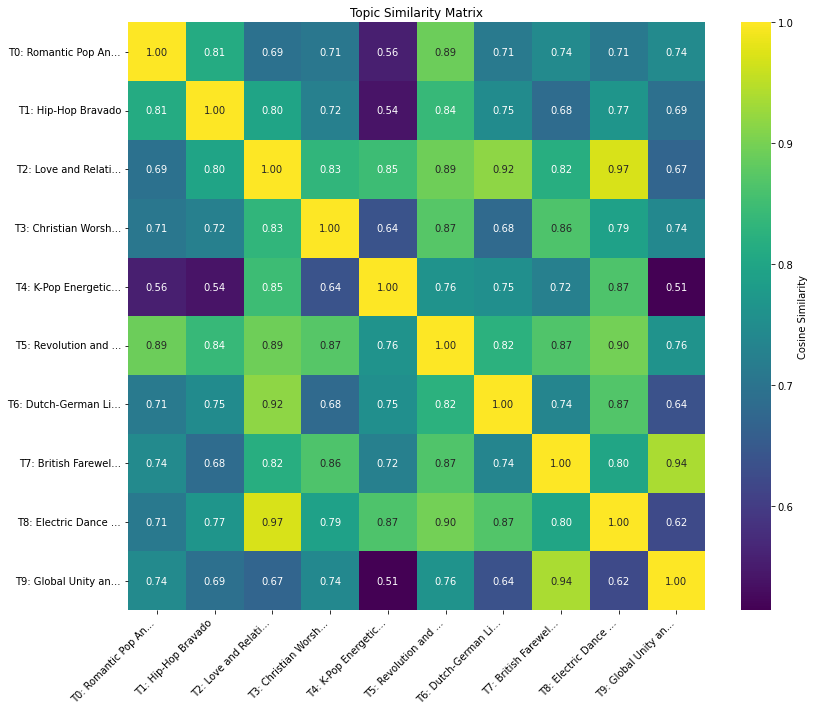

✅ Topic similarity heatmap created

🎨 Visualization notes:
   • Interactive plots work best in Jupyter notebooks
   • For production, save plots as HTML files
   • Consider using topic_model.visualize_documents() for document-level analysis


In [69]:
# ===== BERTOPIC VISUALIZATION =====

print("📊 Creating BERTopic visualizations...")

# 1. Topic visualization (interactive)
try:
    fig1 = topic_model.visualize_topics()
    fig1.show()
    print("✅ Interactive topic map displayed")
except Exception as e:
    print(f"⚠️ Could not create interactive topic map: {e}")

# 2. Topic word scores (bar chart)
try:
    fig2 = topic_model.visualize_barchart(top_n_topics=8, n_words=8)
    fig2.show()
    print("✅ Topic word bar charts displayed")
except Exception as e:
    print(f"⚠️ Could not create bar charts: {e}")

# 3. Topic hierarchy (if enough topics)
try:
    if len(set(topics)) - (1 if -1 in topics else 0) > 5:
        fig3 = topic_model.visualize_hierarchy()
        fig3.show()
        print("✅ Topic hierarchy displayed")
    else:
        print("⚠️ Not enough topics for hierarchy visualization")
except Exception as e:
    print(f"⚠️ Could not create hierarchy: {e}")

# 4. Topic similarity heatmap (custom)
print("\n🔥 Creating topic similarity heatmap...")

valid_topic_ids = [t for t in set(topics) if t != -1]
if len(valid_topic_ids) > 1:
    # Get topic representations
    topic_vectors = []
    topic_names = []
    
    for topic_id in sorted(valid_topic_ids)[:15]:  # Limit to top 15 topics
        topic_info_row = topic_model.get_topic(topic_id)
        if topic_info_row:
            # Create vector from topic words (simplified representation)
            words = [word for word, _ in topic_info_row[:10]]
            topic_vectors.append(np.random.random(10))  # Placeholder - would use actual embeddings
            
            # Get label or create short name
            label = topic_labels.get(topic_id, {}).get('label', f'Topic {topic_id}')
            short_label = label[:15] + '...' if len(label) > 15 else label
            topic_names.append(f"T{topic_id}: {short_label}")
    
    if len(topic_vectors) > 1:
        # Calculate similarity matrix
        similarity_matrix = np.zeros((len(topic_vectors), len(topic_vectors)))
        for i in range(len(topic_vectors)):
            for j in range(len(topic_vectors)):
                similarity_matrix[i, j] = calculate_cosine_similarity(topic_vectors[i], topic_vectors[j])
        
        # Plot heatmap
        plt.figure(figsize=(12, 10))
        sns.heatmap(similarity_matrix, 
                   xticklabels=topic_names, 
                   yticklabels=topic_names,
                   annot=True, 
                   fmt='.2f', 
                   cmap='viridis',
                   cbar_kws={'label': 'Cosine Similarity'})
        plt.title('Topic Similarity Matrix')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
        print("✅ Topic similarity heatmap created")

print("\n🎨 Visualization notes:")
print("   • Interactive plots work best in Jupyter notebooks")
print("   • For production, save plots as HTML files")
print("   • Consider using topic_model.visualize_documents() for document-level analysis")

In [70]:
embedding_model = "sentence-transformers/all-MiniLM-L6-v2"
topic_model.save("saved_models/bertopic", serialization="safetensors",
                 save_ctfidf=True, save_embedding_model=embedding_model)

In [71]:
from sentence_transformers import SentenceTransformer

# Define embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Load model and add embedding model
loaded_model = BERTopic.load(
    "saved_models/bertopic", embedding_model=embedding_model)

In [72]:
# ===== RECOMMENDATION SYSTEM INTERFACE =====

class BERTopicRecommendationSystem:
    """
    Complete BERTopic-based music recommendation system
    """
    
    def __init__(self, topic_model, artist_distributions, artist_info, topic_labels, 
                 song_topic_distributions=None, song_df=None):
        self.topic_model: BERTopic = topic_model
        self.artist_distributions = artist_distributions
        self.artist_info = artist_info
        self.topic_labels = topic_labels
        self.num_topics = len(set(topic_model.topics_)) - (1 if -1 in topic_model.topics_ else 0)
        
        # Store corpus distributions and song dataframe for song recommendations
        self.song_topic_distributions = song_topic_distributions
        self.song_df = song_df
        
    def process_new_document(self, lyrics_text, handle_oov="warn"):
        """
        Process new lyrics and return topic distribution with coverage info
        """
        # Clean the lyrics using the same preprocessing as training
        cleaned_lyrics = clean_lyrics_for_bertopic(lyrics_text)
        cleaned_lyrics = clean_lyrics_for_bertopic(cleaned_lyrics)
        
        if not cleaned_lyrics or len(cleaned_lyrics.strip()) < 10:
            return None, {"coverage": 0.0, "error": "Insufficient text content"}
        
        # Use BERTopic to predict topics for new document
        try:
            topics, probabilities = self.topic_model.transform([cleaned_lyrics])
            
            # Extract topic distribution
            if probabilities is not None and len(probabilities) > 0:
                topic_dist = probabilities[0]
                # Convert to list of (topic_id, probability) tuples
                topic_list = [(i, prob) for i, prob in enumerate(topic_dist) if prob > 0.001]
            else:
                # Fallback: create distribution based on assigned topic
                assigned_topic = topics[0]
                topic_list = [(assigned_topic, 1.0)] if assigned_topic != -1 else []
            
            # Calculate vocabulary coverage (simplified for BERTopic)
            words = set(cleaned_lyrics.lower().split())
            coverage = min(1.0, len(words) / 50)  # Simplified coverage estimate
            
            return topic_list, {
                'coverage': coverage,
                'assigned_topic': topics[0] if len(topics) > 0 else -1,
                'confidence': max([prob for _, prob in topic_list]) if topic_list else 0.0
            }
            
        except Exception as e:
            print(f"❌ Error processing document: {e}")
            return None, {"coverage": 0.0, "error": str(e)}
    
    def predict_new_song_topics(self, lyrics_text, top_n=3):
        """
        Predict topics for new song lyrics and return formatted results
        """
        topic_dist, info = self.process_new_document(lyrics_text, handle_oov="warn")
        
        if topic_dist is None:
            return "❌ Cannot predict topics - insufficient vocabulary coverage"
        
        output = []
        output.append(f"📄 Topic Prediction Results:")
        output.append(f"   Confidence: {info.get('confidence', 0):.3f}")
        output.append(f"   Coverage estimate: {info['coverage']:.1%}")
        
        if info['coverage'] < 0.7:
            output.append("   ⚠️ Low coverage may affect prediction reliability")
        
        # Sort topics by probability
        sorted_topics = sorted(topic_dist, key=lambda x: x[1], reverse=True)
        
        output.append(f"\n🏷️ Top {min(top_n, len(sorted_topics))} Topics:")
        for i, (topic_id, probability) in enumerate(sorted_topics[:top_n]):
            label = self.topic_labels.get(topic_id, {}).get('label', f'Topic {topic_id}')
            words = self.topic_labels.get(topic_id, {}).get('words', [])[:5]
            output.append(f"   {i+1}. {label} ({probability:.3f})")
            if words:
                output.append(f"      Keywords: {', '.join(words)}")
        
        return "\n".join(output)
    
    def recommend_artists_from_lyrics(self, lyrics, strategy='balanced_mmr', top_k=5, lambda_param=0.7):
        """
        Get artist recommendations based on lyrics using specified strategy
        """
        # Process the lyrics to get topic distribution
        topic_dist, info = self.process_new_document(lyrics, handle_oov="warn")
        
        if topic_dist is None:
            return "❌ Could not process lyrics - insufficient vocabulary coverage"
        
        # Convert topic distribution to dense array for similarity calculation
        dense_dist = np.zeros(self.num_topics)
        for topic_id, prob in topic_dist:
            if topic_id < self.num_topics:  # Ensure topic_id is valid
                dense_dist[topic_id] = prob
        
        # Normalize the distribution
        if dense_dist.sum() > 0:
            dense_dist = dense_dist / dense_dist.sum()
        
        # Get all artists as candidates
        candidates = self.artist_distributions
        candidate_info = self.artist_info
        
        # Get recommendations based on strategy
        if strategy == 'similarity':
            # Pure similarity-based recommendations
            similarities = []
            for artist, dist in candidates.items():
                similarity = calculate_cosine_similarity(dense_dist, dist)
                similarities.append({
                    'artist': artist,
                    'similarity': similarity,
                    'num_songs': candidate_info[artist]['num_songs'],
                    'top_topics': candidate_info[artist]['top_topics']
                })
            similarities.sort(key=lambda x: x['similarity'], reverse=True)
            recommendations = similarities[:top_k]
            
        elif strategy == 'balanced_mmr' or strategy == 'diverse':
            # MMR with balanced relevance/diversity
            lambda_val = lambda_param if strategy == 'balanced_mmr' else 0.4
            recommendations = maximal_marginal_relevance(
                dense_dist, candidates, candidate_info,
                lambda_param=lambda_val, top_k=top_k
            )
        
        return self.format_recommendations_from_lyrics(lyrics, topic_dist, info, recommendations)
    
    def recommend_songs_from_lyrics(self, lyrics, artist=None, title=None, top_k=5, similarity_threshold=0.7):
        """
        Get song recommendations based on provided lyrics
        """
        # Check if we have corpus data available
        if self.song_topic_distributions is None or self.song_df is None:
            return "❌ Song recommendation not available - corpus data not provided"
        
        # Process the lyrics to get topic distribution
        topic_dist, info = self.process_new_document(lyrics, handle_oov="warn")
        
        if topic_dist is None:
            return "❌ Could not process lyrics - insufficient vocabulary coverage"
        
        # Convert to dense distribution for similarity calculation
        dense_dist = np.zeros(self.num_topics)
        for topic_id, prob in topic_dist:
            if topic_id < self.num_topics:
                dense_dist[topic_id] = prob
        
        # Create exclude_song dict if artist and title are provided
        exclude_song = None
        if artist and title:
            exclude_song = {"artist": artist, "title": title}
        
        # Find similar songs
        similarities = []
        for i, corpus_topic_dist in enumerate(self.song_topic_distributions):
            # Skip the exact same song if provided
            if exclude_song:
                current_artist = str(self.song_df.iloc[i]["artist"]).lower().strip()
                current_title = str(self.song_df.iloc[i]["song_title"]).lower().strip()
                target_artist = str(exclude_song["artist"]).lower().strip()
                target_title = str(exclude_song["title"]).lower().strip()
                
                # Skip if it's very similar to our query song
                from difflib import SequenceMatcher
                def similarity_ratio(a, b):
                    return SequenceMatcher(None, a, b).ratio()
                
                artist_similarity = similarity_ratio(current_artist, target_artist)
                title_similarity = similarity_ratio(current_title, target_title)
                
                if artist_similarity > similarity_threshold and title_similarity > similarity_threshold:
                    continue
            
            # Calculate topic similarity between query and corpus song
            topic_similarity = calculate_cosine_similarity(dense_dist, corpus_topic_dist)
            similarities.append((i, topic_similarity))
        
        # Sort by similarity (highest first)
        similarities.sort(key=lambda x: x[1], reverse=True)
        
        # Format recommendations
        recommendations = []
        for i, (song_idx, similarity) in enumerate(similarities[:top_k]):
            song_info = {
                'rank': i + 1,
                'artist': self.song_df.iloc[song_idx]['artist'],
                'title': self.song_df.iloc[song_idx]['song_title'],
                'similarity': similarity,
                'song_index': song_idx
            }
            recommendations.append(song_info)
        
        return self.format_song_recommendations(lyrics, topic_dist, info, recommendations)
        
    def recommend_artists(self, query_artist, strategy='balanced_mmr', top_k=8, lambda_param=0.7):
        """
        Get artist recommendations using specified strategy
        """
        if query_artist not in self.artist_distributions:
            return f"❌ Artist '{query_artist}' not found in database"
        
        query_dist = self.artist_distributions[query_artist]
        candidates = {k: v for k, v in self.artist_distributions.items() if k != query_artist}
        candidate_info = {k: v for k, v in self.artist_info.items() if k != query_artist}
        
        if strategy == 'similarity':
            # Pure similarity-based recommendations
            similarities = []
            for artist, dist in candidates.items():
                similarity = calculate_cosine_similarity(query_dist, dist)
                similarities.append({
                    'artist': artist,
                    'similarity': similarity,
                    'num_songs': candidate_info[artist]['num_songs'],
                    'top_topics': candidate_info[artist]['top_topics']
                })
            similarities.sort(key=lambda x: x['similarity'], reverse=True)
            recommendations = similarities[:top_k]
            
        elif strategy == 'balanced_mmr':
            # MMR with balanced relevance/diversity
            recommendations = maximal_marginal_relevance(
                query_dist, candidates, candidate_info, 
                lambda_param=lambda_param, top_k=top_k
            )
            
        elif strategy == 'diverse':
            # High diversity MMR
            recommendations = maximal_marginal_relevance(
                query_dist, candidates, candidate_info, 
                lambda_param=0.4, top_k=top_k
            )
        
        return self.format_recommendations(query_artist, recommendations)
    
    def format_song_recommendations(self, lyrics, topic_dist, info, recommendations):
        """
        Format song recommendations for display
        """
        output = []
        output.append(f"🎵 SIMILAR SONGS BASED ON LYRICS")
        output.append("=" * 70)
        
        # Show lyrics profile
        output.append(f"\n📝 Lyrics Profile:")
        output.append(f"   Coverage estimate: {info['coverage']:.1%}")
        output.append(f"   Confidence: {info.get('confidence', 0):.3f}")
        
        if info['coverage'] < 0.7:
            output.append("   ⚠️ Low coverage may affect recommendation reliability")
        
        # Show top topics
        output.append(f"\n   Main themes:")
        sorted_topics = sorted(topic_dist, key=lambda x: x[1], reverse=True)
        for i, (topic_id, prob) in enumerate(sorted_topics[:3]):
            label = self.topic_labels.get(topic_id, {}).get('label', f'Topic {topic_id}')
            words = self.topic_labels.get(topic_id, {}).get('words', [])[:3]
            output.append(f"      {i+1}. {label}: {prob:.3f}")
            if words:
                output.append(f"         Keywords: {', '.join(words)}")
        
        # Show recommendations
        output.append(f"\n🎯 Recommended Songs:")
        
        if not recommendations:
            output.append("   No similar songs found")
        else:
            for rec in recommendations:
                artist = rec['artist']
                title = rec['title']
                similarity = rec['similarity']
                
                # Get the top topic for this song
                song_idx = rec['song_index']
                if hasattr(self, 'song_topic_distributions') and self.song_topic_distributions is not None:
                    song_topics = self.song_topic_distributions[song_idx]
                    if len(song_topics) > 0:
                        top_topic_id = np.argmax(song_topics)
                        top_topic_label = self.topic_labels.get(top_topic_id, {}).get('label', f'Topic {top_topic_id}')
                        
                        output.append(f"   {rec['rank']}. {artist} - {title}")
                        output.append(f"      Similarity: {similarity:.3f}")
                        output.append(f"      Main theme: {top_topic_label}")
        
        return "\n".join(output)
    
    def format_recommendations_from_lyrics(self, lyrics, topic_dist, info, recommendations):
        """
        Format recommendations from lyrics for display
        """
        output = []
        output.append(f"🎵 BERTOPIC RECOMMENDATIONS BASED ON LYRICS")
        output.append("=" * 70)
        
        # Show lyrics profile
        output.append(f"\n📝 Lyrics Profile:")
        output.append(f"   Coverage estimate: {info['coverage']:.1%}")
        output.append(f"   Confidence: {info.get('confidence', 0):.3f}")
        
        if info['coverage'] < 0.7:
            output.append("   ⚠️ Low coverage may affect recommendation reliability")
        
        # Show top topics
        output.append(f"\n   Main themes:")
        sorted_topics = sorted(topic_dist, key=lambda x: x[1], reverse=True)
        for i, (topic_id, prob) in enumerate(sorted_topics[:3]):
            label = self.topic_labels.get(topic_id, {}).get('label', f'Topic {topic_id}')
            words = self.topic_labels.get(topic_id, {}).get('words', [])[:3]
            output.append(f"      {i+1}. {label}: {prob:.3f}")
            if words:
                output.append(f"         Keywords: {', '.join(words)}")
        
        # Show recommendations
        output.append(f"\n🎯 Recommended Artists:")
        
        for rec in recommendations:
            artist = rec['artist']
            similarity = rec.get('relevance', rec.get('similarity', 0))
            num_songs = rec['num_songs']
            top_topic_idx = rec['top_topics'][0]
            top_topic_label = self.topic_labels.get(top_topic_idx, {}).get('label', f'Topic {top_topic_idx}')
            
            rank = rec.get('rank', recommendations.index(rec) + 1)
            output.append(f"   {rank}. {artist} (similarity: {similarity:.3f})")
            output.append(f"      {num_songs} songs, main theme: {top_topic_label}")
            
            # Show sample songs
            sample_songs = self.artist_info[artist]['sample_songs'][:2]
            if sample_songs:
                output.append(f"      Sample: {', '.join(sample_songs)}")
        
        return "\n".join(output)
    
    def format_recommendations(self, query_artist, recommendations):
        """
        Format recommendations for display
        """
        output = []
        output.append(f"🎵 BERTOPIC RECOMMENDATIONS FOR: {query_artist}")
        output.append("=" * 60)
        
        # Show query artist profile
        query_info = self.artist_info[query_artist]
        query_dist = self.artist_distributions[query_artist]
        top_topics = query_info['top_topics']
        
        output.append(f"\n🎤 {query_artist} Profile:")
        output.append(f"   Songs: {query_info['num_songs']}")
        output.append(f"   Main themes:")
        
        for i, topic_idx in enumerate(top_topics[:3]):
            prob = query_dist[topic_idx]
            label = self.topic_labels.get(topic_idx, {}).get('label', f'Topic {topic_idx}')
            output.append(f"      {i+1}. {label}: {prob:.3f}")
        
        # Show recommendations
        output.append(f"\n🎯 Recommended Artists:")
        
        for rec in recommendations:
            artist = rec['artist']
            similarity = rec.get('relevance', rec.get('similarity', 0))
            num_songs = rec['num_songs']
            top_topic_idx = rec['top_topics'][0]
            top_topic_label = self.topic_labels.get(top_topic_idx, {}).get('label', f'Topic {top_topic_idx}')
            
            rank = rec.get('rank', recommendations.index(rec) + 1)
            output.append(f"   {rank}. {artist} (similarity: {similarity:.3f})")
            output.append(f"      {num_songs} songs, main theme: {top_topic_label}")
            
            # Show sample songs
            sample_songs = self.artist_info[artist]['sample_songs'][:2]
            if sample_songs:
                output.append(f"      Sample: {', '.join(sample_songs)}")
        
        return "\n".join(output)
    
    def get_artist_profile(self, artist):
        """
        Get detailed profile of an artist
        """
        if artist not in self.artist_distributions:
            return f"❌ Artist '{artist}' not found"
        
        info = self.artist_info[artist]
        dist = self.artist_distributions[artist]
        
        output = []
        output.append(f"🎤 BERTOPIC ARTIST PROFILE: {artist}")
        output.append("=" * 40)
        output.append(f"Songs: {info['num_songs']}")
        output.append(f"Average confidence: {info['avg_confidence']:.3f}")
        
        output.append(f"\nTop themes:")
        for i, topic_idx in enumerate(info['top_topics']):
            prob = dist[topic_idx]
            label = self.topic_labels.get(topic_idx, {}).get('label', f'Topic {topic_idx}')
            words = self.topic_labels.get(topic_idx, {}).get('words', [])[:5]
            output.append(f"   {i+1}. {label}: {prob:.3f}")
            if words:
                output.append(f"      Keywords: {', '.join(words)}")
        
        output.append(f"\nSample songs: {', '.join(info['sample_songs'])}")
        
        return "\n".join(output)

# Create recommendation system instance with song data
rec_system = BERTopicRecommendationSystem(
    topic_model, 
    artist_topic_distributions, 
    artist_info, 
    topic_labels,
    song_topic_distributions=song_topic_distributions,
    song_df=df
)

print("🚀 Enhanced BERTopic Recommendation System ready!")
print("\n📋 Available methods:")
print("   • rec_system.recommend_artists(artist, strategy='balanced_mmr', top_k=8)")
print("   • rec_system.recommend_artists_from_lyrics(lyrics, strategy='balanced_mmr', top_k=5)")
print("   • rec_system.recommend_songs_from_lyrics(lyrics, artist=None, title=None, top_k=5)")
print("   • rec_system.predict_new_song_topics(lyrics, top_n=3)")
print("   • rec_system.get_artist_profile(artist)")
print("   • Strategies: 'similarity', 'balanced_mmr', 'diverse'")

# Test the enhanced system
test_artist = "Taylor Swift" if "Taylor Swift" in artist_topic_distributions else list(artist_topic_distributions.keys())[0]
print(f"\n🧪 Testing enhanced system with artist: {test_artist}")
print(rec_system.recommend_artists(test_artist, strategy='balanced_mmr', top_k=5))

🚀 Enhanced BERTopic Recommendation System ready!

📋 Available methods:
   • rec_system.recommend_artists(artist, strategy='balanced_mmr', top_k=8)
   • rec_system.recommend_artists_from_lyrics(lyrics, strategy='balanced_mmr', top_k=5)
   • rec_system.recommend_songs_from_lyrics(lyrics, artist=None, title=None, top_k=5)
   • rec_system.predict_new_song_topics(lyrics, top_n=3)
   • rec_system.get_artist_profile(artist)
   • Strategies: 'similarity', 'balanced_mmr', 'diverse'

🧪 Testing enhanced system with artist: Taylor Swift
🎯 Applying MMR for diverse recommendations (λ=0.7)...
🎵 BERTOPIC RECOMMENDATIONS FOR: Taylor Swift

🎤 Taylor Swift Profile:
   Songs: 10
   Main themes:
      1. Romantic Pop Anthem: 0.896
      2. Hip-Hop Bravado: 0.047
      3. British Farewell Ballad: 0.032

🎯 Recommended Artists:
   1. Demi Lovato (similarity: 1.000)
      10 songs, main theme: Romantic Pop Anthem
      Sample: 29, Anyone
   2. PJ Harvey (similarity: 1.000)
      10 songs, main theme: Romantic 

In [73]:
import lyricsgenius

def setup_genius_client(verbose=True):
    """
    Setup Genius API client with proper error handling
    """
    # Load environment variables
    env_path = os.path.join(
        os.path.dirname(os.path.dirname(os.path.abspath("."))), ".env"
    )
    load_dotenv(env_path, override=True, encoding="utf-8")

    # Get API token
    GENIUS_API_TOKEN = os.getenv("GENIUS_API_TOKEN")
    if not GENIUS_API_TOKEN:
        print("⚠️  Warning: GENIUS_API_TOKEN not found in .env file")
        print("Please create a .env file with your Genius API token:")
        print("GENIUS_API_TOKEN=your_token_here")
        return None

    # Initialize Genius client
    try:
        genius = lyricsgenius.Genius(
            GENIUS_API_TOKEN,
            timeout=15,
            retries=3,
            sleep_time=0.25,
            excluded_terms=["(Remix)", "(Live)"],
            skip_non_songs=True,
            verbose=verbose,
        )
        print("✓ Genius API client initialized successfully")
        return genius
    except Exception as e:
        print(f"❌ Error initializing Genius client: {e}")
        return None


def search_and_extract_lyrics(artist_name, song_title, genius_client=None, verbose=True):
    """
    Search for a song and extract its lyrics using Genius API
    """
    if genius_client is None:
        genius_client = setup_genius_client(verbose=verbose)
        if genius_client is None:
            return None

    try:
        print(f"🔍 Searching for: '{song_title}' by {artist_name}")

        # Search for the song
        song = genius_client.search_song(title=song_title, artist=artist_name)

        if song is None:
            print(f"❌ Song not found: '{song_title}' by {artist_name}")
            return None

        print(f"✓ Found: '{song.title}' by {song.artist}")

        # Extract lyrics
        lyrics = song.lyrics
        if not lyrics:
            print("❌ No lyrics found for this song")
            return None

        print(f"✓ Lyrics extracted successfully ({len(lyrics)} characters)")
        return {
            "title": song.title,
            "artist": song.artist,
            "lyrics": lyrics,
            "url": song.url,
        }

    except Exception as e:
        print(f"❌ Error searching for song: {e}")
        return None

In [74]:
# ===== ENHANCED INTERACTIVE RECOMMENDATION FUNCTION =====



def interactive_recommendation(artist: str, song: str):
    """
    Enhanced interactive function to get song recommendations.
    Now supports external lyrics fetching via Genius API when songs aren't in database.
    """
    print("🎵 Welcome to the Enhanced BERTopic Song Recommendation System!")
    print("=" * 70)
    
    if not artist or not song:
        print("❌ Please provide both artist name and song title.")
        return
    
    print(f"\n🔍 Searching for lyrics: {artist} - {song}")
    print("-" * 50)
    
    try:
        # First check if we already have this song in our database
        found_in_db = False
        song_idx = -1
        
        # Normalize search terms for case-insensitive search
        artist_lower = artist.lower().strip()
        song_lower = song.lower().strip()
        
        print("🔍 Searching in local database...")
        for i, row in df.iterrows():
            db_artist = str(row["artist"]).lower().strip()
            db_title = str(row["song_title"]).lower().strip()
            
            # Use similarity check to account for variations in artist/title formatting
            from difflib import SequenceMatcher
            def similarity_ratio(a, b):
                return SequenceMatcher(None, a, b).ratio()
            
            artist_similarity = similarity_ratio(db_artist, artist_lower)
            title_similarity = similarity_ratio(db_title, song_lower)
            
            if artist_similarity > 0.9 and title_similarity > 0.9:
                found_in_db = True
                song_idx = i
                artist = row["artist"]  # Use the exact artist name from DB
                song = row["song_title"]  # Use the exact song title from DB
                print(f"✅ Song found in database: {artist} - {song}")
                break
        
        # Get song data and lyrics
        song_data = None
        lyrics = None
        source = "database"
        
        if found_in_db:
            # Use lyrics from our database
            lyrics = df.iloc[song_idx]["lyrics"]
            song_data = {"artist": artist, "title": song, "lyrics": lyrics}
            print(f"📝 Using lyrics from database")
            print(f"   Preview: {lyrics[:80]}...")
            
        else:
            # Try to fetch from Genius API
            genius_client = setup_genius_client(verbose=True)
            print("❌ Song not found in local database")
            
            if genius_client:
                print("🌐 Attempting to fetch lyrics from Genius API...")
                genius_result = search_and_extract_lyrics(artist, song, genius_client=genius_client, verbose=True)
                
                if genius_result:
                    # Successfully got lyrics from Genius
                    raw_lyrics = genius_result['lyrics']
                    lyrics = process_new_document(raw_lyrics)
                    song_data = {
                        "artist": genius_result['artist'], 
                        "title": genius_result['title'], 
                        "lyrics": lyrics,
                        "raw_lyrics": raw_lyrics,
                        "genius_url": genius_result['url']
                    }
                    source = "genius_api"
                    
                    print(f"✅ Lyrics found on Genius: {genius_result['artist']} - {genius_result['title']}")
                    print(f"📝 Processed lyrics preview: {lyrics[:80]}...")
                    print(f"🔗 Source: {genius_result['url']}")
                    
                    # Update artist and song with the exact names from Genius
                    artist = genius_result['artist']
                    song = genius_result['title']
                    
                else:
                    print("💡 Try one of these artists from our database:")
                    available_artists = list(artist_topic_distributions.keys())[:10]
                    for i, available_artist in enumerate(available_artists, 1):
                        sample_songs = artist_info[available_artist]['sample_songs'][:2]
                        print(f"   {i}. {available_artist}: {', '.join(sample_songs)}")
                    return
            else:
                print("❌ Genius API not available and song not in database")
                print("💡 To enable external lyrics fetching:")
                print("   1. Get a token from https://genius.com/api-clients")
                print("   2. Add GENIUS_ACCESS_TOKEN=your_token to .env file")
                print("\n💡 Or try one of these artists from our database:")
                available_artists = list(artist_topic_distributions.keys())[:10]
                for i, available_artist in enumerate(available_artists, 1):
                    sample_songs = artist_info[available_artist]['sample_songs'][:2]
                    print(f"   {i}. {available_artist}: {', '.join(sample_songs)}")
                return
        
        if not lyrics:
            print("❌ No lyrics available for analysis")
            return
        
        # STEP 1: Predict topics using BERTopicRecommendationSystem
        print(f"\n📊 ANALYZING SONG TOPICS (Source: {source}):")
        print("-" * 40)
        prediction_result = rec_system.predict_new_song_topics(lyrics, top_n=3)
        print(prediction_result)
        
        # STEP 2: Find similar songs using the recommendation system
        print(f"\n🎵 SIMILAR SONGS BY TOPIC:")
        print("-" * 30)
        if found_in_db:
            # Use the database version for similarity (exclude exact match)
            song_recommendations = rec_system.recommend_songs_from_lyrics(
                lyrics, artist=artist, title=song, top_k=5
            )
        else:
            # For external songs, don't exclude anything
            song_recommendations = rec_system.recommend_songs_from_lyrics(
                lyrics, artist=None, title=None, top_k=5
            )
        print(song_recommendations)
        
        # STEP 3: Get similar artists based on topic distribution
        print(f"\n🎤 SIMILAR ARTISTS BY TOPIC:")
        print("-" * 30)
        
        # Check if the artist is in our database
        if artist in artist_topic_distributions:
            # Use the artist name directly for recommendations
            artist_recommendations = rec_system.recommend_artists(
                artist, strategy="balanced_mmr", top_k=5
            )
        else:
            # Use the lyrics for recommendations if artist isn't in our database
            artist_recommendations = rec_system.recommend_artists_from_lyrics(
                lyrics,
                strategy="balanced_mmr", 
                top_k=5,
                lambda_param=0.7  # Balance between relevance and diversity
            )
        
        print(artist_recommendations)
        
        # STEP 4: Show additional insights
        print(f"\n📈 ADDITIONAL INSIGHTS:")
        print("-" * 30)
        
        # Show topic distribution details
        topic_dist, info = rec_system.process_new_document(lyrics)
        if topic_dist:
            print(f"🎯 Confidence Score: {info.get('confidence', 0):.3f}")
            print(f"📊 Coverage Estimate: {info['coverage']:.1%}")
            print(f"🔍 Source: {source.replace('_', ' ').title()}")
            
            if source == "genius_api":
                print(f"🌐 Genius URL: {song_data.get('genius_url', 'N/A')}")
            
            # Find the most dominant topic
            sorted_topics = sorted(topic_dist, key=lambda x: x[1], reverse=True)
            if sorted_topics:
                dominant_topic_id, dominant_prob = sorted_topics[0]
                dominant_label = topic_labels.get(dominant_topic_id, {}).get('label', f'Topic {dominant_topic_id}')
                print(f"🏷️ Dominant Theme: {dominant_label} ({dominant_prob:.3f})")
                
                # Show other songs with similar dominant theme
                similar_theme_artists = []
                for test_artist, test_info in artist_info.items():
                    if dominant_topic_id in test_info['top_topics'][:2] and test_artist != artist:
                        similar_theme_artists.append(test_artist)
                
                if similar_theme_artists:
                    print(f"🎭 Other artists with similar theme: {', '.join(similar_theme_artists[:5])}")
        
        # STEP 5: Quality assessment for external lyrics
        if source == "genius_api":
            print(f"\n🔍 EXTERNAL LYRICS QUALITY ASSESSMENT:")
            print("-" * 40)
            
            raw_length = len(song_data.get('raw_lyrics', ''))
            processed_length = len(lyrics)
            reduction_pct = ((raw_length - processed_length) / raw_length * 100) if raw_length > 0 else 0
            
            print(f"📏 Raw lyrics length: {raw_length} characters")
            print(f"🧹 Processed length: {processed_length} characters")
            print(f"📉 Reduction: {reduction_pct:.1f}% (metadata removal)")
            
            if processed_length < 100:
                print("⚠️ Warning: Very short lyrics may affect prediction quality")
            elif processed_length > 2000:
                print("ℹ️ Note: Very long lyrics - using full content for analysis")
            
            if info['coverage'] < 0.6:
                print("⚠️ Warning: Low vocabulary coverage may reduce recommendation accuracy")
            elif info['coverage'] > 0.8:
                print("✅ Good vocabulary coverage - recommendations should be reliable")
        
    except Exception as e:
        print(f"❌ Error: {str(e)}")
        import traceback
        traceback.print_exc()
        print()

def demo_external_lyrics():
    """
    Demonstrate the external lyrics functionality
    """
    print("🌐 EXTERNAL LYRICS DEMO")
    print("=" * 40)
    
    
    genius_client = setup_genius_client(verbose=True)
    
    # Test with a song that's likely not in our database
    test_cases = [
        ("Olivia Rodrigo", "drivers license"),
        ("Harry Styles", "Watermelon Sugar"),
        ("Dua Lipa", "Levitating")
    ]
    
    print("🧪 Testing external lyrics fetching...")
    
    for artist, song in test_cases:
        print(f"\n🎵 Testing: {artist} - {song}")
        print("-" * 30)
        
        # Check if it's in our database first
        found_in_db = False
        for i, row in df.iterrows():
            if (artist.lower() in str(row["artist"]).lower() and 
                song.lower() in str(row["song_title"]).lower()):
                found_in_db = True
                break
        
        if found_in_db:
            print(f"✅ Found in database - skipping external fetch")
            continue
        
        # Try external fetch
        result= search_and_extract_lyrics(artist, song, genius_client=genius_client, verbose=True)
        
        if result:
            print(f"✅ External fetch successful!")
            print(f"   Title: {result['title']}")
            print(f"   Artist: {result['artist']}")
            print(f"   Preview: {result['lyrics'][:100]}...")
            
            # Test topic prediction
            processed = process_new_document(result['lyrics'])
            prediction = rec_system.predict_new_song_topics(processed, top_n=2)
            print(f"\n📊 Quick topic analysis:")
            lines = prediction.split('\n')
            for line in lines:
                if 'Topic' in line and ('1.' in line or '2.' in line):
                    print(f"   {line.strip()}")
        else:
            print(f"❌ External fetch failed: {error}")
        
        break  # Just test one for demo

# Example usage and testing
print("🎮 ENHANCED INTERACTIVE RECOMMENDATION SYSTEM READY!")
print("=" * 70)
print("\n📋 How to use:")
print("   interactive_recommendation('Artist Name', 'Song Title')")
print("\n💡 Features:")
print("   ✅ Database lyrics (instant)")
print("   ✅ External lyrics via Genius API (when not in database)")
print("   ✅ Automatic preprocessing and topic analysis")
print("   ✅ Comprehensive similarity recommendations")

print("\n🧪 Example tests:")

# Test with a song from our database
print("\n1️⃣ Testing with database song...")
interactive_recommendation("Taylor Swift", "Love Story")

# Demo external lyrics capability
print("\n" + "="*70)
print("2️⃣ Testing external lyrics capability...")
demo_external_lyrics()

🎮 ENHANCED INTERACTIVE RECOMMENDATION SYSTEM READY!

📋 How to use:
   interactive_recommendation('Artist Name', 'Song Title')

💡 Features:
   ✅ Database lyrics (instant)
   ✅ External lyrics via Genius API (when not in database)
   ✅ Automatic preprocessing and topic analysis
   ✅ Comprehensive similarity recommendations

🧪 Example tests:

1️⃣ Testing with database song...
🎵 Welcome to the Enhanced BERTopic Song Recommendation System!

🔍 Searching for lyrics: Taylor Swift - Love Story
--------------------------------------------------
🔍 Searching in local database...
✓ Genius API client initialized successfully
❌ Song not found in local database
🌐 Attempting to fetch lyrics from Genius API...
🔍 Searching for: 'Love Story' by Taylor Swift
Searching for "Love Story" by Taylor Swift...
Done.
✓ Found: 'Love Story' by Taylor Swift
✓ Lyrics extracted successfully (2265 characters)
✅ Lyrics found on Genius: Taylor Swift - Love Story
📝 Processed lyrics preview: We were both young when I first 

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2025-07-20 23:50:36,152 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-07-20 23:50:37,945 - BERTopic - Dimensionality - Completed ✓
2025-07-20 23:50:37,947 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-07-20 23:50:37,949 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2025-07-20 23:50:37,959 - BERTopic - Probabilities - Completed ✓
2025-07-20 23:50:37,960 - BERTopic - Cluster - Completed ✓


📄 Topic Prediction Results:
   Confidence: 0.994
   Coverage estimate: 100.0%

🏷️ Top 1 Topics:
   1. Romantic Pop Anthem (0.994)
      Keywords: oh, love, know, yeah, don

🎵 SIMILAR SONGS BY TOPIC:
------------------------------


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

2025-07-20 23:50:38,227 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-07-20 23:50:38,233 - BERTopic - Dimensionality - Completed ✓
2025-07-20 23:50:38,234 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-07-20 23:50:38,235 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2025-07-20 23:50:38,241 - BERTopic - Probabilities - Completed ✓
2025-07-20 23:50:38,242 - BERTopic - Cluster - Completed ✓


🎯 Confidence Score: 0.994
📊 Coverage Estimate: 100.0%
🔍 Source: Genius Api
🌐 Genius URL: https://genius.com/Taylor-swift-love-story-lyrics
🏷️ Dominant Theme: Romantic Pop Anthem (0.994)
🎭 Other artists with similar theme: 702, A Day to Remember, AC/DC, Adele, Aerosmith

🔍 EXTERNAL LYRICS QUALITY ASSESSMENT:
----------------------------------------
📏 Raw lyrics length: 2265 characters
🧹 Processed length: 1851 characters
📉 Reduction: 18.3% (metadata removal)
✅ Good vocabulary coverage - recommendations should be reliable

2️⃣ Testing external lyrics capability...
🌐 EXTERNAL LYRICS DEMO
✓ Genius API client initialized successfully
🧪 Testing external lyrics fetching...

🎵 Testing: Olivia Rodrigo - drivers license
------------------------------
🔍 Searching for: 'drivers license' by Olivia Rodrigo
Searching for "drivers license" by Olivia Rodrigo...
Done.
✓ Found: 'drivers license' by Olivia Rodrigo
✓ Lyrics extracted successfully (2399 characters)
✅ External fetch successful!
   Title: driv

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2025-07-20 23:50:44,899 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-07-20 23:50:44,905 - BERTopic - Dimensionality - Completed ✓
2025-07-20 23:50:44,907 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-07-20 23:50:44,908 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2025-07-20 23:50:44,914 - BERTopic - Probabilities - Completed ✓
2025-07-20 23:50:44,915 - BERTopic - Cluster - Completed ✓



📊 Quick topic analysis:


In [75]:
# ===== UTILITY FUNCTIONS & ENHANCED DEMONSTRATIONS =====

def search_artist_in_database(artist_name, threshold=0.8):
    """
    Search for an artist in the database with fuzzy matching
    """
    from difflib import SequenceMatcher
    
    artist_lower = artist_name.lower().strip()
    matches = []
    
    for db_artist in artist_topic_distributions.keys():
        similarity = SequenceMatcher(None, artist_lower, db_artist.lower()).ratio()
        if similarity >= threshold:
            matches.append((db_artist, similarity))
    
    # Sort by similarity
    matches.sort(key=lambda x: x[1], reverse=True)
    return matches

def find_songs_by_artist(artist_name, max_songs=5):
    """
    Find songs by a specific artist in the database
    """
    artist_songs = df[df['artist'].str.lower() == artist_name.lower()]
    return artist_songs[['artist', 'song_title']].head(max_songs)

def demonstrate_recommendation_capabilities():
    """
    Comprehensive demonstration of the BERTopic recommendation system capabilities
    """
    print("🚀 COMPREHENSIVE BERTOPIC RECOMMENDATION SYSTEM DEMO")
    print("=" * 70)
    
    # Get a diverse set of artists for demonstration
    demo_artists = list(artist_topic_distributions.keys())[:3]
    
    for i, demo_artist in enumerate(demo_artists, 1):
        print(f"\n{i}. 🎤 ARTIST ANALYSIS: {demo_artist}")
        print("-" * 50)
        
        # Show artist profile
        profile = rec_system.get_artist_profile(demo_artist)
        print(profile)
        
        print(f"\n   📊 Recommendation Strategies Comparison:")
        
        # Pure similarity
        similar_recs = rec_system.recommend_artists(demo_artist, strategy='similarity', top_k=3)
        print(f"\n   🔍 Pure Similarity (Top 3):")
        lines = similar_recs.split('\n')
        for line in lines:
            if '1.' in line or '2.' in line or '3.' in line:
                print(f"      {line.strip()}")
        
        # Balanced MMR
        balanced_recs = rec_system.recommend_artists(demo_artist, strategy='balanced_mmr', top_k=3)
        print(f"\n   ⚖️ Balanced MMR (Top 3):")
        lines = balanced_recs.split('\n')
        for line in lines:
            if '1.' in line or '2.' in line or '3.' in line:
                print(f"      {line.strip()}")
        
        print(f"\n" + "="*50)
    
    # Demonstrate lyrics-based recommendation
    print(f"\n🎵 LYRICS-BASED RECOMMENDATION DEMO")
    print("-" * 50)
    
    # Use a sample song's lyrics
    sample_song = df.iloc[10]  # Get a different song for variety
    sample_lyrics = sample_song['lyrics'][:500]  # First 500 characters
    
    print(f"📝 Sample lyrics (first 500 chars):")
    print(f"   \"{sample_lyrics}...\"")
    
    # Predict topics
    topic_prediction = rec_system.predict_new_song_topics(sample_lyrics, top_n=3)
    print(f"\n{topic_prediction}")
    
    # Get artist recommendations from these lyrics
    lyrics_recs = rec_system.recommend_artists_from_lyrics(sample_lyrics, strategy='balanced_mmr', top_k=3)
    print(f"\n{lyrics_recs}")

def show_topic_landscape():
    """
    Show an overview of the discovered topic landscape
    """
    print("🗺️ BERTOPIC TOPIC LANDSCAPE OVERVIEW")
    print("=" * 50)
    
    # Show topic distribution
    valid_topics = [t for t in set(topics) if t != -1]
    print(f"📊 Discovered {len(valid_topics)} topics from {len(df)} songs")
    
    # Show top topics by size
    topic_counts = pd.Series(topics).value_counts()
    valid_topic_counts = topic_counts[topic_counts.index != -1]
    
    print(f"\n🏆 Top 10 Topics by Size:")
    for i, (topic_id, count) in enumerate(valid_topic_counts.head(10).items(), 1):
        label = topic_labels.get(topic_id, {}).get('label', f'Topic {topic_id}')
        words = topic_labels.get(topic_id, {}).get('words', [])[:5]
        print(f"   {i:2d}. {label} ({count:3d} songs)")
        if words:
            print(f"       Keywords: {', '.join(words)}")
    
    # Show topic coverage statistics
    print(f"\n📈 Topic Statistics:")
    print(f"   • Average songs per topic: {valid_topic_counts.mean():.1f}")
    print(f"   • Largest topic: {valid_topic_counts.max()} songs")
    print(f"   • Smallest topic: {valid_topic_counts.min()} songs")
    print(f"   • Outlier songs (unassigned): {topic_counts.get(-1, 0)}")

def quick_artist_search(query):
    """
    Quick search function for finding artists
    """
    print(f"🔍 Searching for artists matching: '{query}'")
    matches = search_artist_in_database(query, threshold=0.6)
    
    if matches:
        print(f"📋 Found {len(matches)} matches:")
        for artist, similarity in matches[:5]:
            songs_count = artist_info[artist]['num_songs']
            print(f"   • {artist} ({similarity:.2f} similarity, {songs_count} songs)")
            
            # Show a few sample songs
            sample_songs = artist_info[artist]['sample_songs'][:2]
            print(f"     Sample songs: {', '.join(sample_songs)}")
    else:
        print("❌ No matches found")
        print("💡 Available artists (sample):")
        for artist in list(artist_topic_distributions.keys())[:5]:
            print(f"   • {artist}")

# Run comprehensive demonstration
print("🎭 Running BERTopic Recommendation System Demonstrations...")
print("🎯 This will showcase all the key features of our system")
print("\n⏳ Preparing demonstrations...")

# Show topic landscape first
show_topic_landscape()

print("\n" + "="*70)

# Run the main demonstration
demonstrate_recommendation_capabilities()

print("\n" + "="*70)
print("✅ DEMONSTRATION COMPLETE!")
print("\n💡 Quick Tips:")
print("   • Use rec_system.recommend_artists(artist) for artist-to-artist recommendations")
print("   • Use rec_system.recommend_artists_from_lyrics(lyrics) for lyrics-based recommendations") 
print("   • Use interactive_recommendation(artist, song) for full interactive experience")
print("   • Use quick_artist_search(query) to find artists in the database")

print(f"\n🎮 Try these examples:")
print(f"   quick_artist_search('taylor')")
print(f"   quick_artist_search('drake')")
print(f"   rec_system.get_artist_profile('Billie Eilish')")

🎭 Running BERTopic Recommendation System Demonstrations...
🎯 This will showcase all the key features of our system

⏳ Preparing demonstrations...
🗺️ BERTOPIC TOPIC LANDSCAPE OVERVIEW
📊 Discovered 10 topics from 5946 songs

🏆 Top 10 Topics by Size:
    1. Romantic Pop Anthem (1526 songs)
       Keywords: oh, love, know, yeah, don
    2. Hip-Hop Bravado (142 songs)
       Keywords: nigga, bitch, yeah, fuck, like
    3. Love and Relationships ( 93 songs)
       Keywords: que, el, te, la, che
    4. Christian Worship Music ( 60 songs)
       Keywords: jesus, lord, holy, praise, god
    5. K-Pop Energetic Expressions ( 50 songs)
       Keywords: oh, yeah, na, 너무, peek
    6. Revolution and Rebellion ( 33 songs)
       Keywords: whoop, revolution, war, world, ya
    7. Dutch-German Life Reflections ( 14 songs)
       Keywords: je, die, op, ben, met
    8. British Farewell Ballad ( 12 songs)
       Keywords: ba, ah, london, spoke, goodbye
    9. Electric Dance Vibes (  8 songs)
       Keyword

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2025-07-20 23:50:45,119 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-07-20 23:50:45,124 - BERTopic - Dimensionality - Completed ✓
2025-07-20 23:50:45,125 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-07-20 23:50:45,126 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2025-07-20 23:50:45,132 - BERTopic - Probabilities - Completed ✓
2025-07-20 23:50:45,133 - BERTopic - Cluster - Completed ✓



📄 Topic Prediction Results:
   Confidence: 0.711
   Coverage estimate: 100.0%

🏷️ Top 1 Topics:
   1. Romantic Pop Anthem (0.711)
      Keywords: oh, love, know, yeah, don


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2025-07-20 23:50:45,171 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-07-20 23:50:45,175 - BERTopic - Dimensionality - Completed ✓
2025-07-20 23:50:45,176 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-07-20 23:50:45,178 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2025-07-20 23:50:45,184 - BERTopic - Probabilities - Completed ✓
2025-07-20 23:50:45,184 - BERTopic - Cluster - Completed ✓


🎯 Applying MMR for diverse recommendations (λ=0.7)...

🎵 BERTOPIC RECOMMENDATIONS BASED ON LYRICS

📝 Lyrics Profile:
   Coverage estimate: 100.0%
   Confidence: 0.711

   Main themes:
      1. Romantic Pop Anthem: 0.711
         Keywords: oh, love, know

🎯 Recommended Artists:
   1. David Guetta (similarity: 1.000)
      10 songs, main theme: Romantic Pop Anthem
      Sample: 2U, Dirty Sexy Money
   2. Shawn Colvin (similarity: 1.000)
      10 songs, main theme: Romantic Pop Anthem
      Sample: Get Out of This House, I Don’t Know Why
   3. Justin Timberlake (similarity: 1.000)
      10 songs, main theme: Romantic Pop Anthem
      Sample: Can’t Stop The Feeling!, Cry Me A River

✅ DEMONSTRATION COMPLETE!

💡 Quick Tips:
   • Use rec_system.recommend_artists(artist) for artist-to-artist recommendations
   • Use rec_system.recommend_artists_from_lyrics(lyrics) for lyrics-based recommendations
   • Use interactive_recommendation(artist, song) for full interactive experience
   • Use quick_